# Chapter 30. Inference & Experiments

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch30-inference-and-experiments.md`.

# Chapter 30. Inference & Experiments

*Part 3 — Advanced Analytics & Analytics Engineering*

> **Chapter at a glance**
>
> **You will learn to:** compute a standard error and a confidence interval, by hand and in Python · compare two groups with a t-test and know when it doesn't apply · report an effect size, not only a p-value · test categorical results with a two-proportion test and chi-square · compare several groups with ANOVA without inflating your error rate · calculate the sample size a test needs before you run it · design an A/B test end to end, and write the plan down first · analyze one properly, with a sample-ratio check and guardrail metrics · recognize peeking, multiple testing, novelty effects, and outliers by watching them happen in simulations · read regression coefficients as statements about the business.
>
> **Before you start:** Chapter 18 (pandas, and the NumPy basics in section 18.1), Chapter 21 (distributions, spread, sampling, and the central limit theorem, section 21.8), Chapter 22 (confidence intervals, p-values, chi-square, Type I and II errors, A/B test design, peeking, multiple comparisons, and regression basics in section 22.10), and Chapter 29 (uv projects, and Python as tested code). The box "What's new since Chapter 22", after In plain English, says which parts of this chapter are a recap and which are new.
>
> **Time needed:** 18–22 hours, spread over three weeks, in four sittings: (1) sections 30.1–30.4, standard errors, intervals, the t-test and effect size, about 5 hours; (2) sections 30.5–30.7, proportions, chi-square, ANOVA, power and sample size, about 5 hours, ending with a checkpoint; (3) sections 30.8–30.10, designing the test, analyzing it end to end, and the ways to fool yourself, about 5 hours; (4) sections 30.11–30.12, regression for inference and the write-up, about 4 hours. Allow 2 more for the project.
>
> **Tools:** Python 3.14 as installed in Chapter 17 (any version from 3.11 on runs every example), in a small uv project for this chapter (section 30.1 sets it up), with `pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`, `SQLAlchemy`, and `psycopg`. Everything runs on one laptop in seconds.
>
> **Practice data:** Riverstone's website data, built by `generate_riverstone_web.py` in the companion folder: 214,528 sessions, 622,090 events, and 47,286 visitors in a two-week A/B test. Fixed seed, so your numbers match the book's exactly. The one-year sales database from Chapter 13, `riverstone_2025`, is used for the examples about order values.

---

## Why this matters

Riverstone's marketing agency proposes a new enquiry form. Two weeks later they report: *"Enquiries are up 14%. Roll it out everywhere."*

Four questions decide whether that sentence is worth anything, and all four are this chapter:

- **Is it real, or is it noise?** 14% of what? Over how many visitors? A fortnight of ordinary variation can produce bigger swings than that.
- **How big is the effect, and how sure are we?** "Up 14%" is a point estimate. The honest version is a range, and the range is often wide enough to change the decision.
- **Was the test run properly?** Were visitors split evenly? Did someone check the numbers daily and stop when they looked good? Did the agency test five things and report the one that won?
- **What do we do now?** A result nobody can act on is a cost, not a finding.

Being the person who asks these questions, calmly and with the arithmetic to back them up, is most of what separates a senior analyst from a junior one. It's also the densest interview topic in the whole book: Chapter 73's bank is full of *"how would you design this test"* and *"here's a result, what's wrong with it"*.

---

## In plain English

**Inference is what you say about a whole crowd after talking to a few people in it.**

Suppose you want to know the average height of everyone at a wedding, and you measure ten guests. Your ten-person average won't be exactly the crowd's average, but it won't be wildly off either. The **standard error** measures how far off it's likely to be. Measure forty guests instead of ten, and the error halves: to be twice as precise you need four times as many people, which is why sample size questions have expensive answers.

A **confidence interval** turns that into a sentence you can say out loud: *"the average is 168 cm, give or take 3 cm."* A **hypothesis test** answers a narrower question: *"if the two sides of the room were really the same height, how surprising is the difference I measured?"* Surprising enough, and you stop believing they're the same. The **p-value** is the size of that surprise, and nothing else: not the chance you're wrong, and not the size of the difference.

**An experiment** is how you get a clean answer instead of an argument. Rather than comparing people who happened to see the new form with people who happened not to, you flip a coin for each visitor. Once the coin decides, the two groups differ only by chance and by the form, so a difference between them points at the form.

Three things ruin this, and all three are ordinary human behavior: stopping the moment the numbers look good (**peeking**), trying twenty ideas and reporting the one that worked (**multiple testing**), and the fact that anything new attracts attention for a week (**novelty**). The rest of the chapter is arithmetic; these three are discipline.

> **What's new since Chapter 22.** Chapter 22 taught the ideas on small, tidy examples. This chapter uses them on a real-sized website test, and adds the tools a working analyst needs on top.
>
> - **Recap, kept short, with pointers back:** standard errors and confidence intervals (section 22.1), p-values, chi-square and the two-proportion z-test (section 22.2), A/B test design and sample size (section 22.3), peeking and multiple comparisons (section 22.4), and fitting a line (section 22.10).
> - **New here:** the unit of analysis; effect sizes (Cohen's d, Cramér's V, Cohen's h); ANOVA and Tukey's test; the sample-size formula checked against statsmodels; a whole test analyzed end to end; the sample-ratio check; guardrail metrics; novelty; regression with several variables and categories; and logistic regression with odds ratios.

---

## 30.1 The data, and the question

Riverstone's website, `riverstone.example`, has three tables in the companion data:

| Table | One row is | Rows |
|---|---|---|
| `web_sessions` | one visit: device, browser, channel, region, pages viewed, and whether the visitor sent an enquiry | 214,528 |
| `web_events` | one action inside a session: a page view, a form start, a form submit | 622,090 |
| `ab_test_assignments` | one visitor in the enquiry-form test, and which version they were shown | 47,286 |

### Setting up this chapter's project

Chapter 29 built a full package with uv. This chapter needs much less: a folder whose Python environment has the right libraries, with the versions written down in a lockfile. That's a **bare** uv project. In a terminal, in the companion folder:

**The chapter's output:**

```
# terminal, in companion/ch30
$ uv init --bare
Initialized project `ch30`
$ uv add pandas numpy scipy statsmodels matplotlib sqlalchemy "psycopg[binary]"
Using CPython 3.14.7
Creating virtual environment at: .venv
Resolved 25 packages in 515ms
Prepared 23 packages in 3.10s
Installed 23 packages in 64ms
 + contourpy==1.4.0
 + cycler==0.12.1
 …
$ uv add --dev ipykernel pytest
Resolved 57 packages in 697ms
Prepared 28 packages in 1.05s
Installed 28 packages in 118ms
 + asttokens==3.0.2
 + comm==0.2.3
 …
$ uv run python -c "import sys, scipy, statsmodels; print(sys.version.split()[0], scipy.__version__, statsmodels.__version__)"
3.14.7 1.18.1 0.15.0
```

*(The two package lists are shortened here: the first installs 23 packages, including pandas 3.0.6, numpy 2.5.3, scipy 1.18.1, and statsmodels 0.15.0; the second installs 28. Your version numbers will be the same or newer.)*

- **`uv init --bare`** creates only `pyproject.toml`: no `src/` folder and no sample program, because this chapter's code lives in a notebook, not in a package.
- **`uv add ...`** lists the libraries the chapter uses, creates `.venv`, and writes `uv.lock`, exactly as in section 29.4. `psycopg[binary]` is quoted because some terminals treat square brackets specially.
- **`uv add --dev ipykernel pytest`** adds two tools you only need while working: `ipykernel` lets VS Code run notebook cells with this environment (the **kernel** from Chapter 17, section 17.0), and `pytest` runs the one test in section 30.9.
- **`uv run python -c "..."`** runs one line of Python inside the project's environment and prints the versions, as a check.

Then open the folder in VS Code, create a notebook, and choose the `.venv` environment with **Select Kernel**, as in section 17.0. Every Python cell in this chapter runs in that one notebook, in order.

> **Tool note: or keep your Chapter 17 environment.** It already has every library this chapter uses: pandas, matplotlib, SQLAlchemy, and psycopg from Chapter 18, scipy from Chapter 21, and statsmodels from Chapter 22. The uv project is here because it pins this chapter's versions in `uv.lock`, which is what Chapter 29 recommended for anything you'll want to rerun later.

### Building the data

The generator needs only the Python standard library. It takes about five seconds, and creates a folder `web_data/` with the three tables as CSV files, plus two scripts for loading them into a database:

**The chapter's output:**

```
# terminal, in companion/ch30
$ uv run python generate_riverstone_web.py
sessions 214,528  events 622,090  visitors in the test 47,286
$ ls web_data
ab_test_assignments.csv
load_mysql.sql
load_postgresql.sql
web_events.csv
web_sessions.csv
```

`uv run python` works the same on Windows, macOS, and Linux, so there's no need to remember whether your system calls Python `python3` or `py`.

The test itself, `enquiry_form_2026_02`, ran from 2 to 15 February 2026. Half the visitors saw the existing enquiry form (**control**), half saw a shorter one with fewer required fields (**variant_b**). The business question: *does the shorter form bring more enquiries?*

### The first cells

The first cell loads every library the chapter uses, so later cells don't repeat imports:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_effectsize
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
print("ready")

ready


- `os`, `numpy`, `pandas`, `matplotlib.pyplot` and `scipy.stats` are old friends (Chapters 17, 18, and 21); `create_engine` from SQLAlchemy connects to a database, as in section 18.13.
- The `statsmodels` lines each bring in a few functions from one part of the library. You met `proportions_ztest` in section 22.2; the others are new, and each is explained where it's first used: proportions in section 30.5, power in section 30.7, Tukey's test in section 30.6, multiple-testing corrections in section 30.10, and `smf`, the formula interface for regression, in section 30.11.
- `print("ready")` is only there so the cell shows something when it has finished.

The second cell reads the data:

In [2]:
sessions = pd.read_csv("web_data/web_sessions.csv", parse_dates=["started_at"])
assignments = pd.read_csv("web_data/ab_test_assignments.csv", parse_dates=["assigned_at"])

print(sessions.shape, assignments.shape)
print(sessions[["device", "channel", "pages_viewed", "enquiry_submitted"]].head(3))
print(f"overall enquiry rate: {sessions['enquiry_submitted'].mean():.4f}")

(214528, 12) (47286, 4)
    device   channel  pages_viewed  enquiry_submitted
0  desktop  referral             1                  0
1  desktop  referral             3                  0
2  desktop   organic             2                  0
overall enquiry rate: 0.0359


- `parse_dates=["started_at"]` reads that column as dates and times rather than text (section 18.9), so later cells can compare and sort by it.
- `.shape` gives (rows, columns) for each table; `.head(3)` shows the first three rows of four chosen columns.
- `enquiry_submitted` is 1 when the session sent an enquiry and 0 when it didn't, so its mean is the share of sessions with an enquiry: 3.59%.

> **Simplification note.** Riverstone's site is a stand-in for any website with a form on it, and the data is generated, not collected. Real clickstream data is messier: bots, blocked cookies, visitors who switch devices, sessions that never end. The statistics in this chapter are exactly what you'd run on real data; the cleaning that comes first is Chapters 14 and 47.

---

## 30.2 Standard error and confidence intervals

*(A recap of Chapter 22, section 22.1, now on a large dataset.)* Every sample gives a number that isn't quite the truth. The **standard error** (SE) says how much that number wobbles from sample to sample.

### For an average, by hand

For a mean, the standard error is the standard deviation divided by the square root of the sample size. Start with five sessions, small enough to do with a pencil: they lasted 40, 75, 90, 120, and 210 seconds.

| Session | Seconds, x | x − x̄ | (x − x̄)² |
|---|---:|---:|---:|
| 1 | 40 | −67 | 4,489 |
| 2 | 75 | −32 | 1,024 |
| 3 | 90 | −17 | 289 |
| 4 | 120 | 13 | 169 |
| 5 | 210 | 103 | 10,609 |
| **Total** | **535** | **0** | **16,580** |

1. Mean: x̄ = 535 ÷ 5 = **107 seconds**.
2. Standard deviation: s = √(16,580 ÷ (5 − 1)) = √4,145 = **64.38 seconds**. Dividing by *n* − 1 is Chapter 21's rule for a sample (section 21.2).
3. Standard error: 64.38 ÷ √5 = 64.38 ÷ 2.236 = **28.79 seconds**.
4. With five values, use the t-distribution's multiplier with 5 − 1 = 4 degrees of freedom, *t** = 2.776 (section 22.1), not 1.96. Margin: 2.776 × 28.79 = 79.94.
5. Interval: 107 − 79.94 to 107 + 79.94 = **27.1 to 186.9 seconds**.

In a spreadsheet, with the five values in `A2:A6`: `=STDEV.S(A2:A6)/SQRT(COUNT(A2:A6))` gives the standard error, 28.79, and `=CONFIDENCE.T(0.05,STDEV.S(A2:A6),5)` gives the margin, 79.94.

An interval 160 seconds wide says almost nothing. That's what five sessions buy.

### The same recipe in pandas

Here are the same steps on all 214,528 sessions:

In [3]:
duration = sessions["duration_seconds"]
n = len(duration)
mean = duration.mean()
sd = duration.std(ddof=1)
se = sd / np.sqrt(n)

print(f"n        = {n:,}")
print(f"mean     = {mean:.2f} seconds")
print(f"sd       = {sd:.2f}")
print(f"se       = {se:.3f}")
print(f"95% CI   = {mean - 1.96 * se:.2f} to {mean + 1.96 * se:.2f} seconds")

n        = 214,528
mean     = 96.17 seconds
sd       = 114.91
se       = 0.248
95% CI   = 95.68 to 96.65 seconds


- `duration.std(ddof=1)` is the sample standard deviation, dividing by *n* − 1 as in step 2 (Chapter 21, section 21.2).
- `np.sqrt(n)` is √*n*, so `se` is step 3. The last line is the interval with 1.96 as the multiplier: with 214,528 values, *t** and 1.96 are the same to three decimals.

**Reading it:** individual sessions vary enormously (a standard deviation of 115 seconds against a mean of 96), but the *average* of 214,528 of them is known to within a quarter of a second: the 95% interval is 95.68 to 96.65. That's the whole idea: the sample mean is far more stable than the thing it's averaging.

The **1.96** is the number of standard errors that contains 95% of a normal distribution. For small samples, use the t-distribution instead, as in the hand calculation. scipy does it in one call, which section 22.1 introduced. Take a random 40 sessions:

In [4]:
sample = sessions["duration_seconds"].sample(40, random_state=30)
low, high = stats.t.interval(0.95, df=len(sample) - 1, loc=sample.mean(),
                             scale=stats.sem(sample))
print(f"40 sessions: mean {sample.mean():.1f} s, 95% CI {low:.1f} to {high:.1f} s")

40 sessions: mean 64.0 s, 95% CI 47.8 to 80.2 s


- `.sample(40, random_state=30)` picks 40 rows at random; `random_state=30` fixes the draw so you get the same 40 (Chapter 21, section 21.5).
- `stats.sem(sample)` is the **s**tandard **e**rror of the **m**ean, *s* ÷ √*n*, in one call. It uses *n* − 1 by default.
- `stats.t.interval(0.95, df=..., loc=..., scale=...)` returns the two ends: the confidence level, the degrees of freedom (40 − 1 = 39), the center (`loc`, the sample mean), and the standard error (`scale`), exactly as in section 22.1. `low, high = ...` unpacks the two ends into two names.

Notice that this interval, 47.8 to 80.2 seconds, does not contain 96.17 seconds, the mean of all 214,528 sessions. That can happen: 95% intervals miss 1 time in 20. With skewed data like this it happens more often in small samples, because a sample of 40 rarely includes the few very long visits that pull the mean up (the longest session lasts 4,300 seconds). Section 30.3 comes back to skewed data; for measures like this, prefer larger samples, or the bootstrap from section 22.2.

Forty sessions give an interval tens of seconds wide; 214,528 give one a fraction of a second wide. **Precision costs data, and it costs it at the square root**: four times the data for twice the precision.

![Four horizontal intervals, all centered on plus 0.55 percentage points: at 2,500 per group the interval spans minus 0.56 to plus 1.66 and crosses zero, at 10,000 it just touches zero, at 25,000 it runs 0.20 to 0.90, and at 100,000 it runs 0.38 to 0.73](figures/fig30-1-confidence-intervals.svg)

*Figure 30.1 — The same measured lift, four sample sizes. Only the sample size changed, and with it what you may say.*

### For a proportion

Conversion rates are proportions, and their standard error has its own formula: the square root of *p(1 − p) / n* (section 22.1). A rate needs a unit to count, and the test randomizes visitors, so first make one row per visitor:

In [5]:
visitors = (sessions.groupby("visitor_id")["enquiry_submitted"].max()
                    .rename("enquired").reset_index())
print(visitors.head(3))
print(len(visitors))

  visitor_id  enquired
0   v0000001         0
1   v0000002         0
2   v0000003         0
176000


Read the chain one step at a time:

- `groupby("visitor_id")` makes one group per visitor, holding all of that visitor's sessions.
- `["enquiry_submitted"].max()` takes the largest value in each group. The values are 0 and 1, so the maximum is 1 if *any* of the visitor's sessions sent an enquiry: it means "ever enquired".
- `.rename("enquired")` gives the result that name; `.reset_index()` turns `visitor_id` back from the row labels into an ordinary column.

176,000 visitors made the 214,528 sessions. Now the rate, its standard error, and the interval:

In [6]:
k = int(visitors["enquired"].sum())
n = len(visitors)
p = k / n
se = np.sqrt(p * (1 - p) / n)

print(f"{k:,} of {n:,} visitors sent an enquiry")
print(f"rate     = {p:.4f}  ({p * 100:.2f}%)")
print(f"se       = {se:.5f}")
print(f"95% CI   = {100 * (p - 1.96 * se):.2f}% to {100 * (p + 1.96 * se):.2f}%")

7,643 of 176,000 visitors sent an enquiry
rate     = 0.0434  (4.34%)
se       = 0.00049
95% CI   = 4.25% to 4.44%


- `visitors["enquired"].sum()` counts the 1s, the visitors who enquired; `int(...)` makes it a plain whole number.
- `se` is √(p(1 − p) / n), line for line, and the interval is p ± 1.96 × se, printed as percentages.

**Watch the unit of analysis.** The rate above is per *visitor*, not per *session*: a visitor who came three times and enquired once counts as one converted visitor. The test randomizes visitors, so visitors are what you count. Mixing the two is one of the most common errors in A/B analysis, and it quietly inflates your sample size, which makes everything look more significant than it is.

> **Watch out: a confidence interval is about the method, not the number.** "95% confident" means that if you repeated this sampling many times, 95% of the intervals you built this way would contain the true value. It does *not* mean there's a 95% chance the truth is inside this particular interval; the truth is fixed, and the interval is what varies. In a meeting, say it as a range: *"between 4.25% and 4.44%"*. That's what people actually need.

---

## 30.3 Comparing two groups: the t-test

*"Do Wholesale customers place bigger orders than Retail ones?"* This is Chapter 13's sales data, and the tool is Welch's **two-sample t-test** from section 22.2: it asks how surprising the difference between two averages would be if the two groups really had the same average.

First, the orders. The connection details come from the environment variable `RIVERSTONE_DATABASE_URL`, set as in section 29.3, so the password never appears in the notebook. Set it in the terminal before you start VS Code, or keep it in a `.env` file that Git ignores:

In [ ]:
engine = create_engine(os.environ["RIVERSTONE_DATABASE_URL"])
orders = pd.read_sql("""
    SELECT sl.order_id, c.segment, SUM(sl.net_revenue) AS order_value
    FROM sales_lines AS sl
    JOIN customers AS c ON c.customer_id = sl.customer_id
    GROUP BY sl.order_id, c.segment
""", engine)
print(orders.shape)
print(orders["segment"].value_counts().sort_index())

> **Not run here.** This cell needs something this machine does not have: a database, an API key, a running service, or command-line arguments. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
(173, 3)
segment
Hospitality    59
Retail         59
Wholesale      55
Name: count, dtype: int64
```

- `os.environ["RIVERSTONE_DATABASE_URL"]` reads the variable. If it isn't set, the cell stops with a `KeyError` naming it, which tells you exactly what to fix.
- The query adds up each order's lines from Chapter 13's `sales_lines` view, with the customer's segment. `sales_lines` already carries `order_id`, so no join to `orders` is needed, and it already leaves out cancelled orders (section 13.2): that's why there are 173 orders, not 175.
- `pd.read_sql(query, engine)` runs it and returns a DataFrame (section 18.13). `.value_counts().sort_index()` counts the orders per segment, in alphabetical order.

Next, the two groups to compare:

In [ ]:
retail = orders.loc[orders["segment"] == "Retail", "order_value"]
wholesale = orders.loc[orders["segment"] == "Wholesale", "order_value"]

print(f"Retail:    n = {len(retail):3d}, mean = {retail.mean():9,.0f}, sd = {retail.std():9,.0f}")
print(f"Wholesale: n = {len(wholesale):3d}, mean = {wholesale.mean():9,.0f}, sd = {wholesale.std():9,.0f}")

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
Retail:    n =  59, mean =    25,233, sd =    15,719
Wholesale: n =  55, mean =    30,957, sd =    21,094
```

`.loc[condition, "order_value"]` keeps the rows of one segment and the one column (section 18.4). In the f-strings, `:3d` prints a whole number in 3 characters and `:9,.0f` a number with thousands commas, no decimals, in 9 characters, so the columns line up.

Now the test:

In [ ]:
result = stats.ttest_ind(wholesale, retail, equal_var=False)
print(f"difference = {wholesale.mean() - retail.mean():,.0f}")
print(f"t = {result.statistic:.3f}, p = {result.pvalue:.4f}, df = {result.df:.1f}")
ci = result.confidence_interval()
print(f"95% CI for the difference: {ci.low:,.0f} to {ci.high:,.0f}")

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
difference = 5,724
t = 1.634, p = 0.1055, df = 99.5
95% CI for the difference: -1,228 to 12,676
```

**How it works:**

- **`equal_var=False`** runs **Welch's t-test**, which doesn't assume the two groups have the same spread. Use it by default: it costs almost nothing when the spreads do match, and it's right when they don't.
- **t** is the difference measured in standard errors. By hand, Welch's standard error is √(s₁²/n₁ + s₂²/n₂) = √(21,094²/55 + 15,719²/59) = ₹3,504, and t = 5,724 ÷ 3,504 = 1.63. **p** is the chance of seeing a difference at least this large if the true difference were zero.
- **df**, the degrees of freedom, come from a formula that allows for the two spreads being unequal: 99.5 here, a little under the *n*₁ + *n*₂ − 2 = 112 an equal-spread test would use. Fewer degrees of freedom mean a slightly larger *t** and a slightly wider interval.
- `result.confidence_interval()` is a method of the result, so it needs the brackets. It returns an object with two parts, `.low` and `.high`: the **confidence interval for the difference**. That's the part to quote. It answers *"how much bigger?"*, which is the business question; the p-value only answers *"could this be nothing?"*.

**What this particular result says.** Wholesale orders averaged ₹30,957 against Retail's ₹25,233, a difference of ₹5,724, but p = 0.1055 and the interval runs from −₹1,228 to +₹12,676. The interval contains zero, so 114 orders can't tell these two segments apart: the honest answer is *"we don't know yet"*, not *"Wholesale orders are 23% bigger"*. That's Chapter 22's warning about small samples, now measured. Section 30.7 works out how many orders would be needed to settle it.

### What the p-value does not say

A recap of section 22.2's table, because these four misreadings turn up in every meeting:

| People often say | What it actually means |
|---|---|
| "There's a 2% chance the result is wrong" | No. It's the chance of data this extreme *if there were no difference at all* |
| "p = 0.04 means the effect is real; p = 0.06 means there's nothing there" | 0.05 is a convention, not a boundary in nature. Report the number and the interval |
| "p = 0.001 means the effect is big" | No. With enough data, a trivial difference gets a tiny p-value. See section 30.4 |
| "p = 0.3 proves the two are the same" | No. It means this test couldn't tell them apart, which is also what too little data looks like |

### When a t-test isn't the right tool

The t-test compares means and assumes the *sample means* are roughly normally distributed. With samples of 30 or more that's usually fine even for skewed data, thanks to the central limit theorem (Chapter 21). Two situations need care:

- **Very skewed data with heavy tails**, such as Riverstone's enquiry values, where the largest enquiry (₹43.9 lakh) is worth nearly 200 ordinary ones (the median is ₹22,747). Then the mean itself may be the wrong summary: compare medians (the Mann-Whitney U test), or analyze log values, or cap the extremes, and say which you did.
- **Data that isn't independent**: several sessions from the same visitor, or several orders from the same customer. Aggregate to the randomization unit first, as section 30.2 did.

In [10]:
enquiries = sessions.loc[sessions["enquiry_submitted"] == 1, "enquiry_value"]
print(f"n = {len(enquiries):,}")
print(f"mean   = {enquiries.mean():,.0f}")
print(f"median = {enquiries.median():,.0f}")
print(f"largest three: {[f'{v:,.0f}' for v in enquiries.nlargest(3)]}")
print(f"the top 1% of enquiries hold {100 * enquiries.nlargest(len(enquiries) // 100).sum() / enquiries.sum():.1f}% of the value")

n = 7,711
mean   = 41,045
median = 22,747
largest three: ['4,388,000', '2,679,214', '2,002,875']
the top 1% of enquiries hold 16.6% of the value


- `enquiries.nlargest(3)` returns the three biggest values (Chapter 21). The list comprehension inside the f-string, `[f'{v:,.0f}' for v in ...]` (Chapter 17), formats each one; the `:,` format groups digits in threes, so 4,388,000 is ₹43,88,000 in the Indian style.
- `len(enquiries) // 100` is 1% of the count, as a whole number (`//` divides and drops the remainder): the 77 largest enquiries. Their total, divided by the total of all enquiries, is the top 1%'s share.

The mean (₹41,045) is almost twice the median (₹22,747), and 77 enquiries out of 7,711 hold a sixth of the value. That's the shape of data where a mean comparison can swing on a single row. Section 30.10 returns to it.

---

## 30.4 Effect size: how big, not just whether

A p-value answers *"could this be nothing?"*. It says nothing about *how much*, and with a large enough sample almost any difference gets a small p-value. Watch that happen:

In [11]:
rng = np.random.default_rng(30)
group_a = rng.normal(100.0, 15, 200_000)
group_b = rng.normal(100.3, 15, 200_000)     # a difference of 0.3 in 15: trivial

t = stats.ttest_ind(group_b, group_a, equal_var=False)
d = (group_b.mean() - group_a.mean()) / np.sqrt((group_a.var(ddof=1) + group_b.var(ddof=1)) / 2)
print(f"difference = {group_b.mean() - group_a.mean():.3f}")
print(f"p-value    = {t.pvalue:.1e}")
print(f"Cohen's d  = {d:.3f}")

difference = 0.298
p-value    = 3.1e-10
Cohen's d  = 0.020


- `rng.normal(100.0, 15, 200_000)` draws 200,000 values from a normal distribution with mean 100 and standard deviation 15 (section 22.7 used the same call). Group B's mean is 100.3.
- The t-test is section 30.3's. `:.1e` prints the p-value in scientific notation (section 22.2): `3.1e-10` is 3.1 × 10⁻¹⁰, nine zeros after the decimal point and then 31. A p-value is never exactly zero; printed with six decimals, this one would show as `0.000000`, which hides it.
- `d` is **Cohen's d**: the difference in means divided by the **pooled standard deviation**, the square root of the average of the two variances. It measures the gap in standard deviations, so it doesn't grow with the sample.

A difference of three tenths of a point, on a scale where people vary by 15, is not worth a meeting. The p-value calls it significant because the sample is enormous. **Significant means "measurable", not "important".**

**Effect size** measures importance on a scale that doesn't grow with the sample:

| Measure | For | Formula | Rough reading |
|---|---|---|---|
| **Absolute difference** | anything | mean₂ − mean₁, or p₂ − p₁ | in the units the business uses |
| **Relative lift** | rates | (p₂ − p₁) / p₁ | "14% more enquiries" |
| **Cohen's d** | two means | difference ÷ pooled standard deviation | 0.2 small, 0.5 medium, 0.8 large |
| **Odds ratio** | proportions in regression | taught in section 30.11 | 1.0 is no effect |
| **Cramér's V** | chi-square tables | taught in section 30.5 | 0 to 1, higher is stronger |

Riverstone's real difference in visit length, between sessions that sent an enquiry and sessions that didn't:

In [12]:
enquired = sessions.loc[sessions["enquiry_submitted"] == 1, "duration_seconds"]
browsed = sessions.loc[sessions["enquiry_submitted"] == 0, "duration_seconds"]
d = (enquired.mean() - browsed.mean()) / np.sqrt((enquired.var(ddof=1) + browsed.var(ddof=1)) / 2)

print(f"enquired: n = {len(enquired):,}, mean = {enquired.mean():.1f} s")
print(f"browsed:  n = {len(browsed):,}, mean = {browsed.mean():.1f} s")
print(f"Cohen's d = {d:.2f}")

enquired: n = 7,711, mean = 173.9 s
browsed:  n = 206,817, mean = 93.3 s
Cohen's d = 0.51


- The two `.loc` lines split the sessions' `duration_seconds` by `enquiry_submitted`: 1 for sessions that enquired, 0 for the rest.
- `d` is the Cohen's d formula from the first cell, applied to the two groups.

Sessions that end in an enquiry last nearly twice as long, and a d of 0.51 is a medium effect by the table's rough reading: a real difference, and one you could see on a chart.

**Always report three numbers together**: the effect (with its unit), the confidence interval, and the sample size. Section 30.9's result, as a preview: *"Enquiries rose 0.55 percentage points (95% CI 0.19 to 0.91), from 3.90% to 4.45%, over 47,286 visitors"* is a complete sentence. *"p < 0.01"* is not.

> **Watch out: relative lift on a small base is a rhetorical device.** A rise from 0.1% to 0.2% is "a 100% improvement" and also one extra enquiry per thousand visitors. Give both forms every time: the absolute change tells people what will land in their inbox, the relative one tells them how much the thing they changed mattered.

---

## 30.5 Categorical outcomes: proportions and chi-square

Most experiment metrics are proportions: converted or not, clicked or not, churned or not. Two tools cover them.

### Two proportions

The difference between two rates, with its standard error, is section 30.2's arithmetic applied twice, and section 22.2's z-test. Which channels bring visitors who enquire? First give each visitor a channel. A visitor can come back through a different channel, so use one rule and say it: **a visitor's channel is the channel of their first visit**.

In [13]:
first_visit = sessions.sort_values("started_at").drop_duplicates("visitor_id")
by_visitor = visitors.merge(first_visit[["visitor_id", "channel", "device", "region"]], on="visitor_id")
counts = by_visitor.groupby("channel")["enquired"].agg(["sum", "count"])
print(counts)

           sum  count
channel              
direct    2236  42037
email      769  12485
organic   2685  66885
paid      1131  35179
referral   822  19414


- `sort_values("started_at")` puts every session in time order; `drop_duplicates("visitor_id")` then keeps the first row it meets for each visitor, which is their first visit (section 18.10).
- `visitors.merge(..., on="visitor_id")` adds that visit's channel, device, and region to each visitor's `enquired` flag (section 18.7). Device and region are for later sections. In this generated data every visitor keeps the same channel and device on every visit; real visitors don't, which is why the rule matters.
- `.agg(["sum", "count"])` gives two columns per channel: the visitors who enquired and all visitors.

Now compare email with paid search:

In [14]:
k_email, n_email = counts.loc["email", "sum"], counts.loc["email", "count"]
k_paid, n_paid = counts.loc["paid", "sum"], counts.loc["paid", "count"]
stat, pvalue = proportions_ztest([k_email, k_paid], [n_email, n_paid])
low, high = confint_proportions_2indep(k_email, n_email, k_paid, n_paid, method="wald")

print(f"email {k_email / n_email:.4f} vs paid {k_paid / n_paid:.4f}")
print(f"z = {stat:.2f}, p = {pvalue:.2e}")
print(f"95% CI for the difference: {low:.4f} to {high:.4f}")

email 0.0616 vs paid 0.0321
z = 14.45, p = 2.60e-47
95% CI for the difference: 0.0248 to 0.0340


**How it works:**

- `counts.loc["email", "sum"]` picks one cell: the row `email`, the column `sum`. Each line unpacks two cells into two names.
- `proportions_ztest([k_email, k_paid], [n_email, n_paid])` takes a list of successes, then a list of totals, as in section 22.2. The order sets the sign: email comes first, so a positive z means email's rate is higher. It returns z (`stat`) and the p-value.
- `confint_proportions_2indep(k_email, n_email, k_paid, n_paid, method="wald")` gives the 95% interval for the first rate minus the second. `method="wald"` is the textbook formula from section 22.1: the difference ± 1.96 × √(p₁(1 − p₁)/n₁ + p₂(1 − p₂)/n₂).
- `:.2e` prints the p-value in scientific notation: 2.60e-47 is a decimal point, 46 zeros, then 26.

Check the interval by hand: 0.0616 − 0.0321 = 0.0294; the standard error is √(0.0616 × 0.9384 ÷ 12,485 + 0.0321 × 0.9679 ÷ 35,179) = 0.00235; and 0.0294 ± 1.96 × 0.00235 runs from **0.0248 to 0.0340** ✓.

Why two functions rather than one? The test asks *"what if there were no difference?"*, so it computes its standard error as if the two groups shared one rate, the **pooled standard error**: here the pooled rate is 1,900 ÷ 47,664 = 0.0399, and the pooled SE is 0.00204, which gives z = 0.0294 ÷ 0.00204 = 14.45. The interval describes the difference you actually have, so it uses each group's own rate. The two standard errors differ a little, so compute each with its own function, and don't be surprised if a p-value just under 0.05 comes with an interval that just touches zero.

### Chi-square: several categories at once

*"Does enquiry rate depend on the channel at all?"* A **chi-square test of independence** compares the counts you observed with the counts you'd expect if the two columns were unrelated. Section 22.2 worked one through by hand on a 2×2 table; here the table is 5×2:

In [15]:
table = pd.crosstab(by_visitor["channel"], by_visitor["enquired"])
chi2, p, dof, expected = stats.chi2_contingency(table)
cramers_v = np.sqrt(chi2 / (table.to_numpy().sum() * (min(table.shape) - 1)))

print(table)
print(f"chi-square = {chi2:.1f}, dof = {dof}, p = {p:.3e}")
print(f"Cramér's V = {cramers_v:.3f}")
print("expected counts if channel made no difference:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns).round(0))

enquired      0     1
channel              
direct    39801  2236
email     11716   769
organic   64200  2685
paid      34048  1131
referral  18592   822
chi-square = 321.3, dof = 4, p = 2.772e-68
Cramér's V = 0.043
expected counts if channel made no difference:
enquired        0       1
channel                  
direct    40211.0  1826.0
email     11943.0   542.0
organic   63980.0  2905.0
paid      33651.0  1528.0
referral  18571.0   843.0


**How it works:**

- `pd.crosstab` counts visitors for every (channel, enquired) pair (Chapter 21). `stats.chi2_contingency(table)` returns four things, unpacked into four names: the statistic, its p-value, the degrees of freedom, and the table of expected counts.
- The test adds up, over every cell, how far the observed count is from the expected one, relative to the expected one. Large total, small p-value.
- **Degrees of freedom** is (rows − 1) × (columns − 1).
- A significant chi-square says *"these columns are related"*, not *which* cell drives it. Compare observed against expected to see that, then test the specific pair you care about, as above.
- **Cramér's V** is the effect size: √(χ² ÷ (*n* × (the smaller of rows and columns − 1))), which runs from 0 (no relationship) to 1. In the code, `table.to_numpy().sum()` is *n*, all 176,000 visitors, and `min(table.shape) - 1` is 2 − 1 = 1. The relationship here is real and small, which is typical of channel data.
- The test needs reasonable counts in each cell (a common rule: every expected count at least 5). For rare outcomes in small samples, use Fisher's exact test instead (`stats.fisher_exact`).

> **Watch out: significant does not mean causal.** Email visitors enquire more often than paid ones, but people on the mailing list already know Riverstone. The channel didn't cause the enquiry; the relationship with the company did. That's section 22.5's correlation-and-causation point, and it's exactly what an experiment fixes, by deciding the groups with a coin instead of letting visitors sort themselves.

---

## 30.6 More than two groups: ANOVA

Comparing four regions with t-tests means six comparisons, and each one carries its own 5% chance of a false alarm (section 22.4's family-wise error rate). **Analysis of variance (ANOVA)** asks one question instead: *"is there any difference among these groups?"*

### The idea, by hand

ANOVA compares two kinds of variation: how far the group means are from each other (**between** groups), and how far the values are from their own group's mean (**within** groups). If the groups really were alike, the gaps between their means would be about the size that the scatter within groups produces anyway. Take three channels and three visitors each, with the pages they viewed:

| Channel | Pages viewed | Group mean |
|---|---|---:|
| A | 2, 3, 4 | 3 |
| B | 3, 4, 5 | 4 |
| C | 5, 6, 7 | 6 |

1. The grand mean of all nine values is 39 ÷ 9 = 4.33.
2. **Between groups:** each group mean's distance from the grand mean, squared, times the 3 values in the group: 3 × ((3 − 4.33)² + (4 − 4.33)² + (6 − 4.33)²) = 3 × 4.67 = **14.0**. There are 3 groups, so 3 − 1 = **2** degrees of freedom, and 14.0 ÷ 2 = **7.0**.
3. **Within groups:** each value's distance from its own group mean, squared: (1 + 0 + 1) in each group, so 2 + 2 + 2 = **6.0**. There are 9 values in 3 groups, so 9 − 3 = **6** degrees of freedom, and 6.0 ÷ 6 = **1.0**.
4. **F = 7.0 ÷ 1.0 = 7.0.** The gaps between the means are seven times what the scatter within groups would explain.

> **The formula: the F statistic.** F = (between-group variation ÷ (*k* − 1)) ÷ (within-group variation ÷ (*N* − *k*))
>
> - ***k*** is the number of groups and ***N*** the number of values. Each variation is a sum of squared distances, as in steps 2 and 3.
> - When the groups are alike, F is close to 1. The bigger F is, the harder it is to explain the gaps between groups as noise.

scipy does the same arithmetic, and adds the p-value:

In [16]:
f_toy, p_toy = stats.f_oneway([2, 3, 4], [3, 4, 5], [5, 6, 7])
print(f"F = {f_toy:.2f}, p = {p_toy:.4f}")

F = 7.00, p = 0.0270


`stats.f_oneway` takes each group as a separate argument, here three lists, and returns F and its p-value. F = 7.00 matches the hand answer.

### On Riverstone's visitors

The unit of analysis comes first (section 30.2): one row per visitor, not per session, or a visitor who came three times counts three times. Average each visitor's sessions, and add the channel and region from `by_visitor`:

In [17]:
averages = sessions.groupby("visitor_id")[["duration_seconds", "pages_viewed"]].mean().reset_index()
visitor_table = by_visitor.merge(averages, on="visitor_id")
print(visitor_table.shape)

(176000, 7)


`groupby("visitor_id")[[...]].mean()` gives each visitor's average visit length and average pages per visit; the merge puts them next to the visitor's channel, device, region, and `enquired` flag: 176,000 rows, 7 columns.

`stats.f_oneway` needs one list of values per group. A `for` loop over a `groupby` hands you the groups one at a time, as pairs of (name, group):

In [18]:
for name, group in visitor_table.groupby("region"):
    print(name, len(group))

East 21458
North 38637
South 45511
West 70394


Each time round the loop, `name` is the region and `group` is a DataFrame of that region's visitors. Now the ANOVA, first for visit length by region, then for pages viewed by channel:

In [19]:
by_region = [g["duration_seconds"].to_numpy() for _, g in visitor_table.groupby("region")]
f_stat, p_value = stats.f_oneway(*by_region)
print(visitor_table.groupby("region")["duration_seconds"].agg(["count", "mean"]).round(1))
print(f"F = {f_stat:.3f}, p = {p_value:.4f}")

by_channel = [g["pages_viewed"].to_numpy() for _, g in visitor_table.groupby("channel")]
f_stat, p_value = stats.f_oneway(*by_channel)
print(visitor_table.groupby("channel")["pages_viewed"].agg(["count", "mean"]).round(2))
print(f"F = {f_stat:.2f}, p = {p_value:.3f}")

        count  mean
region             
East    21458  95.4
North   38637  96.5
South   45511  95.4
West    70394  96.8
F = 1.917, p = 0.1245
          count  mean
channel              
direct    42037  2.75
email     12485  2.77
organic   66885  2.73
paid      35179  2.73
referral  19414  2.75
F = 2.57, p = 0.036


- The list comprehension (Chapter 17) builds one NumPy array per region, with `.to_numpy()` (section 18.1). `_` is Python's name for a value you don't need, here the region's name (section 22.2 used it the same way).
- `*by_region` unpacks the list: `stats.f_oneway(*by_region)` is the same as writing `stats.f_oneway(east, north, south, west)`, each array as a separate argument, without knowing in advance how many groups there are.
- The `groupby(...).agg(["count", "mean"])` lines print each group's size and mean, so you can see what the test is comparing.

**Reading it:** the four regions behave the same: F is small (1.9) and p = 0.12, so there's no evidence of any difference in how long visits last. The five channels do differ in pages viewed, at p = 0.036. Run the same test on sessions instead, and the channel p-value drops to 0.013: counting each visit as independent makes the evidence look stronger than it is, which is section 30.2's warning in action.

ANOVA says *something* differs. To find out what, run a **post-hoc test** that corrects for the number of comparisons. **Tukey's test** (Tukey HSD, for "honestly significant difference") compares every pair of groups while holding the family-wise error rate at 5%:

In [20]:
sample = visitor_table.sample(20_000, random_state=30)
tukey = pairwise_tukeyhsd(sample["pages_viewed"], sample["channel"], alpha=0.05)
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
 direct    email   0.0922 0.4251 -0.0545 0.2388  False
 direct  organic    0.028  0.911 -0.0607 0.1167  False
 direct     paid   0.0178   0.99 -0.0856 0.1212  False
 direct referral   0.0184 0.9944  -0.106 0.1428  False
  email  organic  -0.0642 0.7247 -0.2047 0.0764  False
  email     paid  -0.0743 0.6599 -0.2246 0.0759  False
  email referral  -0.0737 0.7419 -0.2391 0.0917  False
organic     paid  -0.0102 0.9984 -0.1047 0.0843  False
organic referral  -0.0096 0.9995 -0.1267 0.1075  False
   paid referral   0.0006    1.0  -0.128 0.1292  False
------------------------------------------------------


- `pairwise_tukeyhsd(values, groups, alpha=0.05)` takes the values, then the group label for each value, then the family-wise error rate to hold. `.summary()` prints the table. It runs on a random 20,000 visitors to keep it quick.
- **FWER=0.05** in the title is the **family-wise error rate** (section 22.4): the chance of at least one false alarm across all ten pairs, held at 5%.
- `meandiff` is group2's mean minus group1's. **`p-adj`** is each pair's p-value after allowing for ten comparisons, and `lower`/`upper` is the 95% interval for the difference. `reject = True` would mean "these two differ".

**Not one pair is rejected here**, and that's the lesson, not a failure: look again at the channel means, which run from 2.73 to 2.77 pages. On 176,000 visitors that gap is measurable (p = 0.036); on a 20,000-visitor sample no individual pair stands out; and in either case it is a few hundredths of a page. This is section 30.4 arriving from the other direction: before asking whether a difference is significant, ask whether the difference would change anything.

Why the correction matters, in one simulation: twenty comparisons between groups that are all identical.

In [21]:
rng = np.random.default_rng(30)
false_alarms = 0
for _ in range(20):
    a = rng.normal(100, 15, 500)
    b = rng.normal(100, 15, 500)          # exactly the same population
    if stats.ttest_ind(a, b).pvalue < 0.05:
        false_alarms += 1
print(f"comparisons: 20, 'significant' results: {false_alarms}")
print(f"chance of at least one false alarm in 20 tests at 5%: {1 - 0.95 ** 20:.1%}")

comparisons: 20, 'significant' results: 2
chance of at least one false alarm in 20 tests at 5%: 64.2%


- Each time round the loop, `a` and `b` are 500 values drawn from the *same* normal distribution (mean 100, standard deviation 15), so any "difference" is chance.
- `stats.ttest_ind(a, b)` without `equal_var=False` is the ordinary t-test (section 22.10); `.pvalue` reads its p-value. `false_alarms += 1` counts the tests that come out below 0.05.
- The last line is section 22.4's arithmetic, 1 − 0.95²⁰: the chance that at least one of twenty tests raises a false alarm.

Nothing differed, and yet results appeared. Run twenty tests at the 5% level and you'd expect one false alarm; the chance of at least one is 64%. That's the arithmetic behind section 30.10's multiple-testing rule.

---

## 30.7 Power and sample size

*(A recap of section 22.3, which defined power, Type I and II errors, and the minimum detectable effect, and worked out a sample size by hand.)* **Statistical power** is the chance a test detects an effect that's really there. The convention is 80%, and it depends on four things, any three of which fix the fourth:

| Quantity | Meaning | Usual choice |
|---|---|---|
| **α (alpha)** | chance of a false positive you'll accept | 0.05 |
| **Power (1 − β)** | chance of catching a real effect | 0.80 |
| **Effect size** | the smallest difference worth detecting (the **minimum detectable effect**, MDE) | a business decision |
| **n** | sample size per group | what you're solving for |

Section 22.3 used the full formula. Most calculators use a shorter version, which gives almost the same answer:

> **The formula: sample size per group for two proportions (short version).** *n* = 2 × (z<sub>α/2</sub> + z<sub>β</sub>)² × p̄(1 − p̄) ÷ d²
>
> - **z<sub>α/2</sub>** = 1.960, the multiplier for a two-sided test at 5%: `stats.norm.ppf(0.975)` (Chapter 21, section 21.5).
> - **z<sub>β</sub>** = 0.842, the multiplier for 80% power: `stats.norm.ppf(0.80)`.
> - **p̄** is the average of the two rates, the baseline and the baseline plus the MDE.
> - **d** is the MDE in proportion units: 0.005 for half a percentage point. It is *not* Cohen's d from section 30.4.

By hand, for Riverstone's enquiry rate of 3.9% and an MDE of half a point:

1. The two rates are 0.039 and 0.044, so p̄ = 0.0415 and p̄(1 − p̄) = 0.0415 × 0.9585 = 0.03978.
2. (1.960 + 0.842)² = 2.802² = 7.851.
3. *n* = 2 × 7.851 × 0.03978 ÷ 0.005² = 0.6246 ÷ 0.000025 = **24,984 visitors per group**.

The same in Python, keeping every decimal:

In [22]:
baseline = 0.039           # Riverstone's enquiry rate before the test
mde = 0.005                # we care about half a percentage point
z_alpha, z_beta = stats.norm.ppf(1 - 0.05 / 2), stats.norm.ppf(0.80)
p_bar = baseline + mde / 2
n_by_hand = 2 * (z_alpha + z_beta) ** 2 * p_bar * (1 - p_bar) / mde ** 2

print(f"z_alpha = {z_alpha:.3f}, z_beta = {z_beta:.3f}")
print(f"by hand:     {n_by_hand:,.0f} visitors per group")

z_alpha = 1.960, z_beta = 0.842
by hand:     24,977 visitors per group


`p_bar = baseline + mde / 2` is the average of 0.039 and 0.044, and `n_by_hand` is the formula, line for line. The hand answer was 24,984 because it rounded the multipliers to three decimals. (Section 22.3's full formula gives 24,976: the two versions agree to within a visitor.)

statsmodels solves the same problem on a slightly different scale:

In [23]:
effect = proportion_effectsize(baseline + mde, baseline)
n_statsmodels = NormalIndPower().solve_power(effect_size=effect, alpha=0.05, power=0.80, alternative="two-sided")

print(f"Cohen's h:   {effect:.4f}")
print(f"statsmodels: {n_statsmodels:,.0f} visitors per group")
print(f"total needed: {2 * n_statsmodels:,.0f} visitors")

Cohen's h:   0.0251
statsmodels: 24,955 visitors per group
total needed: 49,909 visitors


- `proportion_effectsize(0.044, 0.039)` turns the two rates into **Cohen's h**, an effect size for proportions: h = 2 × arcsin √p₂ − 2 × arcsin √p₁ = 0.0251. It's a rescaled difference that makes a move from 3.9% to 4.4% comparable with a move from 50% to 50.5%, because a half-point move near 0% is harder to detect than one near 50%.
- `NormalIndPower()` is the power calculator for two independent groups compared with a normal (z) test. `.solve_power(...)` works whichever way round you need: **give it every quantity except the one you want, and it returns that one**. Here `nobs1`, the sample size of the first group, is left out, so it solves for it.
- `alternative="two-sided"` matches a test that counts a difference in either direction.

24,955 and 24,977 differ by 22 visitors because h works on the arcsine scale; either rounds to 25,000 per group.

**What happens if you change it.** Before running the next cell, predict: if the smallest lift worth detecting halves, from 0.5 points to 0.25, what happens to the sample size?

In [24]:
for small_lift in (0.0025, 0.005, 0.01):
    h = proportion_effectsize(baseline + small_lift, baseline)
    n_needed = NormalIndPower().solve_power(effect_size=h, alpha=0.05, power=0.80)
    print(f"MDE {100 * small_lift:.2f} points: {n_needed:>9,.0f} visitors per group")

MDE 0.25 points:    97,002 visitors per group
MDE 0.50 points:    24,955 visitors per group
MDE 1.00 points:     6,582 visitors per group


Halving the MDE roughly quadruples the sample, because the effect is squared in the formula's denominator; doubling it cuts the sample to about a quarter. That's why the MDE is the most expensive line in any test plan, and why it has to come from the business.

At about 3,400 new visitors a day, half in each group, reaching 25,000 per group takes a fortnight. Which is exactly how the fortnight in section 30.1 was chosen: **the duration came from the arithmetic, not from the calendar.**

![A rising curve showing power against visitors per group for a 0.5 percentage point effect on a 3.9% baseline: 24% power at 5,000 per group, 80% at 25,000, and 98% at 50,000](figures/fig30-2-power-curve.svg)

*Figure 30.2 — Power against sample size. Riverstone's fortnight was chosen to land on the 80% mark.*

The curve is one call to the same calculator, asked for power instead of sample size, at sixty sample sizes at once:

power at  5,000 per group: 0.24
power at 25,000 per group: 0.80


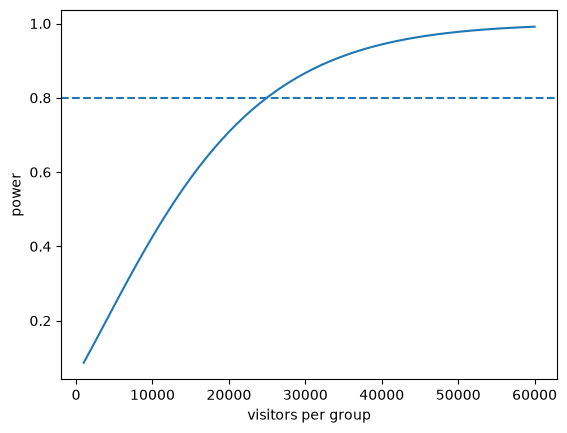

In [25]:
ns = np.arange(1_000, 60_001, 1_000)
power = NormalIndPower().power(effect_size=effect, nobs1=ns, alpha=0.05)
print(f"power at  5,000 per group: {power[ns == 5_000][0]:.2f}")
print(f"power at 25,000 per group: {power[ns == 25_000][0]:.2f}")

plt.plot(ns, power)
plt.axhline(0.8, linestyle="--")
plt.xlabel("visitors per group")
plt.ylabel("power")
plt.show()

- `np.arange(1_000, 60_001, 1_000)` makes the sample sizes 1,000, 2,000, … 60,000. The stop value, 60,001, is left out, as with `range`, so 60,000 is the last.
- `.power(effect_size=..., nobs1=ns, alpha=0.05)` is the other direction: given the effect and a sample size, what's the power? Because `ns` is an array, it returns sixty powers, one per sample size.
- `power[ns == 5_000]` picks the power where the sample size is 5,000 (a Boolean mask, section 18.1), and `[0]` takes the single value out of the array.
- `plt.plot` draws the curve, and `plt.axhline(0.8, linestyle="--")` a dashed line at 80%, as in section 22.10. Figure 30.2 is the same chart, labeled.

Two more things the same machinery answers.

**What effect could this test have detected?** Run it backwards from the sample you actually have. This time leave out `effect_size` and give `nobs1`:

In [26]:
detectable = NormalIndPower().solve_power(nobs1=24_000, alpha=0.05, power=0.80, alternative="two-sided")
print(f"effect size (Cohen's h) detectable with 24,000 per group: {detectable:.4f}")
print(f"that is roughly {detectable * np.sqrt(baseline * (1 - baseline)) * 100:.2f} percentage points")

effect size (Cohen's h) detectable with 24,000 per group: 0.0256
that is roughly 0.50 percentage points


The second line turns h back into percentage points, roughly: near a rate p, one unit of h is about √(p(1 − p)) in proportion units. With 24,000 visitors per group, the smallest lift the test could reliably catch was half a point, which is what the plan asked for.

**How many orders would settle section 30.3's question?** Retail and Wholesale differed by ₹5,724 with a pooled standard deviation of about ₹18,500:

In [ ]:
d = (wholesale.mean() - retail.mean()) / np.sqrt((retail.var(ddof=1) + wholesale.var(ddof=1)) / 2)
needed = TTestIndPower().solve_power(effect_size=d, alpha=0.05, power=0.80, alternative="two-sided")
print(f"observed Cohen's d = {d:.3f}")
print(f"orders needed per segment for 80% power: {needed:,.0f}")
print(f"orders available: Retail {len(retail)}, Wholesale {len(wholesale)}")

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
observed Cohen's d = 0.308
orders needed per segment for 80% power: 167
orders available: Retail 59, Wholesale 55
```

`TTestIndPower()` is the calculator for comparing two means with a t-test, and it takes Cohen's d (section 30.4) as its effect size. Here we use the observed gap only as a starting guess for a *future* study. A better answer asks the sales head what gap in average order value would change a decision (say ₹5,000) and plans for that, as the Watch out below says.

So the answer to *"is the difference real?"* is *"ask again when we have three years of orders"*, and that's a useful thing to be able to say with a number attached.

> **Watch out: power calculations done afterwards are not evidence.** Computing "the power we had to detect the effect we observed" (sometimes called post-hoc power) tells you nothing new: it's just the p-value in different clothes. Power belongs *before* the test, with an effect size chosen from the business, not from the data.

### Checkpoint: the end of the second sitting

Before section 30.8, check that sample sizes are yours. Email visitors enquire at about 6%. The marketing team wants to test a new email landing page and cares about a lift of 1 percentage point.

1. By hand, with the short formula: how many visitors per group, at 5% significance and 80% power?
2. Check it with `proportion_effectsize` and `NormalIndPower().solve_power`.
3. Email brings about 7% of Riverstone's 3,400 daily visitors. How many weeks would the test take? (Answers at the end of the chapter.)

---

## 30.8 Designing an experiment

Everything above is arithmetic. The design is where tests are won or lost, and it belongs in a written plan agreed before a single visitor is randomized. Riverstone's plan for the enquiry-form test fits on one page:

| Section | Riverstone's answer |
|---|---|
| **Question** | Does a shorter enquiry form bring more enquiries? |
| **Change** | `variant_b`: five fields instead of nine, phone number optional |
| **Primary metric** | Enquiry rate per visitor (enquiries ÷ visitors) |
| **Guardrail metrics** | Pages viewed per visitor; sessions per visitor; median enquiry value; enquiry-to-order rate in the CRM |
| **Randomization unit** | Visitor (not session, not page view) |
| **Split** | 50/50, assigned on first session during the window |
| **Minimum detectable effect** | 0.5 percentage points on a 3.9% baseline |
| **Sample size** | 24,955 visitors per group, rounded to 25,000 (section 30.7) |
| **Duration** | 2–15 February 2026: two full weeks, whole weeks only |
| **Stopping rule** | Run to the planned end. No decisions from interim looks |
| **Analysis plan** | Two-proportion test, 95% CI, effect size; sample-ratio check first; segments reported as exploratory only |
| **Decision rule** | Ship if the interval's lower bound is above 0 and no guardrail worsens; otherwise keep the current form |

![Eight steps in order, four marked before the test (question, metric and guardrails, MDE and sample size, duration and stopping rule), one during, and three after (sample-ratio check, primary metric with interval, effect size and decision)](figures/fig30-3-experiment-order.svg)

*Figure 30.3 — Everything above the line is decided before a visitor is randomized.*

**Why each choice matters:**

- **One primary metric.** Choosing the winner afterwards from five metrics is multiple testing with extra steps. Everything else is a guardrail: watched to catch damage, not used to declare victory.
- **The randomization unit must match the analysis unit.** Randomize visitors, count visitors.
- **Whole weeks.** Weekday and weekend behavior differ (the data has a real weekend effect); a test that ends on a Wednesday weights midweek twice.
- **A stopping rule written in advance** is what makes the p-value mean what it says. Section 30.10 shows the damage when there isn't one.
- **Guardrails are as important as the metric.** A form that gets more enquiries by asking for less information may bring worse leads. That's why *enquiry-to-order rate* is on the list, even though it can't be measured for weeks.
- **A decision rule** turns a result into an action before anyone has a stake in the answer.

> **Try it.** Write this table for a change you'd like to test where you work: a subject line, a page layout, a follow-up call within an hour. Most people find the *metric* and *decision rule* rows the hard ones, which is the point: they're where the disagreement lives, and it's cheaper to have it now.

---

## 30.9 Riverstone's website test, end to end

The plan is written, the fortnight has passed. Analysis follows the plan, in order, starting with the checks that can invalidate everything else.

### Step 1: assemble the data at the right grain

First, the sessions that belong to the test: visitors who were assigned a version, visiting during the fortnight.

In [28]:
test_sessions = sessions.merge(assignments, on="visitor_id")
window = test_sessions["started_at"].between("2026-02-02", "2026-02-15 23:59:59")
test_sessions = test_sessions.loc[window]
first = test_sessions.sort_values("started_at").drop_duplicates("visitor_id")
print(len(test_sessions), len(first))

53692 47286


- `sessions.merge(assignments, on="visitor_id")` keeps only the sessions of visitors in the test, and adds each one's `variant`. A merge keeps only matching rows unless you ask otherwise (section 18.7).
- `.between("2026-02-02", "2026-02-15 23:59:59")` is True for sessions that started in the window, both ends included (section 18.4). pandas compares the text with the dates for you; the end is written as the last second of 15 February, so that the whole last day counts.
- `first` holds each visitor's first session in the test, the same `sort_values` and `drop_duplicates` pair as in section 30.5. Step 5, section 30.10, and section 30.11 use it for each visitor's device, browser, and channel.

53,692 sessions from 47,286 visitors. Now one row per visitor, and one summary row per version:

In [29]:
per_visitor = (test_sessions.groupby(["variant", "visitor_id"])
               .agg(enquired=("enquiry_submitted", "max"),
                    sessions=("session_id", "count"),
                    pages=("pages_viewed", "sum"),
                    value=("enquiry_value", "max"))
               .reset_index())
summary = per_visitor.groupby("variant").agg(visitors=("visitor_id", "count"),
                                             enquiries=("enquired", "sum"))
summary["rate"] = summary["enquiries"] / summary["visitors"]
print(summary)

           visitors  enquiries      rate
variant                                 
control       24036        937  0.038983
variant_b     23250       1035  0.044516


- `groupby(["variant", "visitor_id"])` makes one group per visitor, keeping their version. `.agg(...)` is Chapter 18's named aggregation: `enquired` is the largest `enquiry_submitted` (1 if any session enquired, as in section 30.2), `sessions` counts the visitor's sessions, `pages` adds up their pages, and `value` is the largest enquiry value (empty, `NaN`, for visitors who didn't enquire).
- `summary` counts the visitors and adds up the enquirers for each version, and `rate` divides one by the other.

### Step 2: the sample-ratio check, before anything else

A 50/50 split should produce group sizes that differ only by chance. If they don't, something is wrong with the assignment or the logging, and the outcome numbers can't be trusted either. Test it with a different chi-square test from section 30.5's: a **goodness-of-fit test**, which compares observed counts with the counts a rule says to expect.

In [30]:
observed = summary["visitors"].to_numpy()
chi2, p_srm = stats.chisquare(observed)
print(f"visitors: control {observed[0]:,}, variant_b {observed[1]:,}")
print(f"split: {observed[0] / observed.sum():.3%} / {observed[1] / observed.sum():.3%}")
print(f"sample-ratio mismatch test: chi-square = {chi2:.1f}, p = {p_srm:.5f}")

visitors: control 24,036, variant_b 23,250
split: 50.831% / 49.169%
sample-ratio mismatch test: chi-square = 13.1, p = 0.00030


- `.to_numpy()` turns the `visitors` column into a plain array of two counts, `observed[0]` for control and `observed[1]` for the variant.
- `stats.chisquare(observed)` compares the observed counts with expected ones. With no `f_exp=` argument, it expects equal counts: 47,286 ÷ 2 = 23,643 each. That default is exactly right for a 50/50 design. For a 90/10 design you would pass `f_exp=[0.9 * total, 0.1 * total]`, where `total` is the number of visitors in the test.
- `:.3%` prints a proportion as a percentage with three decimals.

By hand, as in section 22.2: (24,036 − 23,643)² ÷ 23,643 + (23,250 − 23,643)² ÷ 23,643 = 6.53 + 6.53 = **13.1** ✓.

**This test fails.** A 50.8/49.2 split of 47,286 visitors sounds harmless, but chance alone would produce a gap this large about once in 3,300 tests (p = 0.0003). That's a **sample-ratio mismatch (SRM)**, and the rule is firm: investigate before reading the result. Section 30.10 finds the cause.

### Step 3: the primary metric, with an interval

In [31]:
k = summary["enquiries"].to_numpy()
n = summary["visitors"].to_numpy()
p_control, p_variant = k / n
diff = p_variant - p_control
se = np.sqrt(p_control * (1 - p_control) / n[0] + p_variant * (1 - p_variant) / n[1])
z, p_value = proportions_ztest([k[1], k[0]], [n[1], n[0]])

print(f"control   {p_control:.4f}  ({k[0]:,} of {n[0]:,})")
print(f"variant_b {p_variant:.4f}  ({k[1]:,} of {n[1]:,})")
print(f"absolute difference: {100 * diff:+.2f} percentage points")
print(f"relative lift:       {100 * diff / p_control:+.1f}%")
print(f"z = {z:.3f}, p = {p_value:.4f}")
print(f"95% CI (absolute):   {100 * (diff - 1.96 * se):+.2f} to {100 * (diff + 1.96 * se):+.2f} pp")
low_rel, high_rel = (diff - 1.96 * se) / p_control, (diff + 1.96 * se) / p_control
print(f"95% CI (relative):   {100 * low_rel:+.1f}% to {100 * high_rel:+.1f}%")

control   0.0390  (937 of 24,036)
variant_b 0.0445  (1,035 of 23,250)
absolute difference: +0.55 percentage points
relative lift:       +14.2%
z = 3.009, p = 0.0026
95% CI (absolute):   +0.19 to +0.91 pp
95% CI (relative):   +4.9% to +23.4%


- `k` and `n` are arrays of two numbers each, control first (the order of `summary`'s rows). `k / n` divides them element by element, and `p_control, p_variant = k / n` unpacks the two rates into two names (Chapter 17).
- `se` is the standard error of the difference, from section 22.1's formula, with each group's own rate.
- `proportions_ztest([k[1], k[0]], [n[1], n[0]])` lists the variant first, so that a positive z means the variant is higher. As in section 30.5, the test uses the pooled standard error and the interval uses the unpooled one; here they are 0.001839 and 0.001841, the same for any practical purpose.
- The relative interval divides both ends of the absolute interval by the control rate. That treats the control rate as known exactly, which it isn't quite. A more careful interval for a ratio, calculated on the log scale, gives +4.7% to +24.5%: the same story.

The agency's "up 14%" is the middle of a range that runs from +4.9% to +23.4%. At Riverstone's traffic of about 3,400 new visitors a day, 0.55 percentage points is roughly 560 extra enquiries a month, and the interval's ends are about 200 and 930. Both ends are good news; the gap between them is the difference between hiring another person to handle enquiries and not. The range belongs in the report.

### Making it repeatable: a tested function

Section 29.7 tested the monthly report against numbers everyone had agreed. The same habit works for statistics. Save the arithmetic of Step 3 as a function in a file, `ab_summary.py`, in the chapter folder:

In [32]:
"""Chapter 30: the two-proportion summary used in section 30.9, as a function that can be tested."""
import numpy as np
from statsmodels.stats.proportion import proportions_ztest


def two_proportion_summary(k_a: int, n_a: int, k_b: int, n_b: int) -> dict:
    """Compare group B's rate with group A's: the difference, its 95% interval, and the p-value."""
    p_a, p_b = k_a / n_a, k_b / n_b
    diff = p_b - p_a
    se = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
    z, p_value = proportions_ztest([k_b, k_a], [n_b, n_a])
    return {"diff": diff, "ci_low": diff - 1.96 * se, "ci_high": diff + 1.96 * se, "p_value": p_value}

It's Step 3's lines, with the type hints of section 29.6: four whole numbers in (`k_a` and `n_a`, group A's enquirers and visitors, then the same for group B), a dictionary out, with the difference, the two ends of its interval, and the p-value. The notebook can now import it and use it for any test:

In [33]:
from ab_summary import two_proportion_summary

result = two_proportion_summary(k[0], n[0], k[1], n[1])
print({name: round(float(value), 4) for name, value in result.items()})

{'diff': 0.0055, 'ci_low': 0.0019, 'ci_high': 0.0091, 'p_value': 0.0026}


The dictionary comprehension (Chapter 17) rounds each value to four decimals for printing; `float(...)` turns NumPy's number types into plain Python ones, so they print as numbers. Then pin the book's numbers in a test, `test_ab_summary.py`, in the same folder:

In [34]:
import pytest
from ab_summary import two_proportion_summary


def test_enquiry_form_matches_the_book():
    result = two_proportion_summary(937, 24_036, 1_035, 23_250)
    assert result["diff"] == pytest.approx(0.0055, abs=0.0001)
    assert result["ci_low"] == pytest.approx(0.0019, abs=0.0001)
    assert result["ci_high"] == pytest.approx(0.0091, abs=0.0001)
    assert result["p_value"] == pytest.approx(0.0026, abs=0.0001)

> **Not run here.** The chapter marks this block as illustration rather than something to execute, usually because it needs a service, a key or a file this notebook does not set up. Read it, do not run it.

As in section 29.7, pytest runs every function whose name starts with `test_`, and each `assert` line must be true for the test to pass. `pytest.approx(0.0055, abs=0.0001)` means "equal to 0.0055, give or take 0.0001" (section 29.7 used `approx` without `abs`, which allows a tiny relative difference instead). Run it from the terminal:

**The chapter's output:**

```
# terminal, in companion/ch30
$ uv run pytest -q
.                                                                        [100%]
1 passed in 2.80s
```

`uv run pytest` runs pytest inside the project's environment, and `-q` (quiet) prints one character per test: the single dot is the one test, passing. If someone later "tidies" the function and breaks it, this test fails before the wrong number reaches a report. It's Chapter 29's reconciliation test, applied to statistics.

### Step 4: guardrails

The plan named three guardrails that can be measured now: pages viewed per visitor, sessions per visitor, and the size of the enquiries.

In [35]:
guard = per_visitor.groupby("variant").agg(pages=("pages", "mean"),
                                           sessions=("sessions", "mean"),
                                           median_value=("value", "median"))
print(guard.round(3))

enq = per_visitor.dropna(subset=["value"])
u = stats.mannwhitneyu(enq.loc[enq["variant"] == "variant_b", "value"],
                       enq.loc[enq["variant"] == "control", "value"])
print(f"enquiry value, variant_b vs control: Mann-Whitney p = {u.pvalue:.3f}")

           pages  sessions  median_value
variant                                 
control    3.092     1.135      23066.35
variant_b  3.130     1.136      22764.70
enquiry value, variant_b vs control: Mann-Whitney p = 0.952


- `guard` averages each visitor's pages and sessions within each version, and `median_value` takes the median enquiry value. The median skips the empty values of visitors who didn't enquire.
- `dropna(subset=["value"])` keeps only the visitors with an enquiry value (section 18.10). Enquiry values are heavily skewed (section 30.3), so they are compared with the Mann-Whitney test from section 22.2, which uses ranks, not the values themselves.

Pages viewed and sessions per visitor are unchanged, and the enquiry values are indistinguishable, so the extra enquiries show no sign of being worse. The guardrail that matters most, how many of these enquiries become orders, can't be answered for weeks, and the write-up should say so rather than implying the question is closed.

### Step 5: segments, clearly labeled as exploratory

In [36]:
seg = (per_visitor.merge(first[["visitor_id", "device"]], on="visitor_id")
       .groupby(["device", "variant"])
       .agg(visitors=("visitor_id", "count"), rate=("enquired", "mean"))
       .reset_index())
print(seg.pivot(index="device", columns="variant", values=["visitors", "rate"]).round(4))

        visitors              rate          
variant  control variant_b control variant_b
device                                      
desktop  10933.0   10852.0  0.0466    0.0519
mobile   11659.0   11031.0  0.0329    0.0378
tablet    1444.0    1367.0  0.0298    0.0402


- The merge adds each visitor's device, from their first session in the test (`first`, Step 1). The `groupby` and `agg` then count visitors and average `enquired`, the enquiry rate, for every (device, variant) pair.
- `.pivot(index="device", columns="variant", values=["visitors", "rate"])` spreads the long table out: devices down the side, and for each of the two values, one column per version. It's `pivot_table` (section 18.8) without the aggregation, for a table that already has one row per cell. The counts print as `10933.0` because the pivot stores both values in columns of decimals.

Every segment moves in the same direction, which is mildly reassuring. What you must not do is pick the biggest one and report *"a 35% lift on tablet"* (0.0298 to 0.0402), on only 2,811 tablet visitors, whose interval is far wider than the overall one: three devices means three more chances of a false positive, and the test was never powered for a single device. Segments are for generating the *next* hypothesis.

---

## 30.10 Four ways to fool yourself, demonstrated

### Peeking

Section 22.4 showed what peeking does to an email test. Here is the same trap in the shape of Riverstone's website test. Checking daily and stopping when p first drops below 0.05 sounds prudent. Simulate it on two groups that are identical by construction. First, the settings:

In [37]:
rng = np.random.default_rng(30)
rate = 0.039
trials = 200
print(f"{trials} simulated tests, both groups at {rate:.1%}, one look a day for 14 days")

200 simulated tests, both groups at 3.9%, one look a day for 14 days


`rate` is Riverstone's enquiry rate before the test, and `trials` is how many fortnights to simulate. Then the fortnights themselves:

In [38]:
peeks_that_won = 0
for _ in range(trials):
    a = rng.random(14_000) < rate          # two identical groups
    b = rng.random(14_000) < rate
    for day in range(1, 15):               # look once a day for two weeks
        upto = day * 1000
        _, p = proportions_ztest([a[:upto].sum(), b[:upto].sum()], [upto, upto])
        if p < 0.05:
            peeks_that_won += 1
            break

share = peeks_that_won / trials
print(f"{trials} tests where nothing was different")
print(f"'significant' at some point while peeking: {peeks_that_won} ({share:.1%})")
print("expected at a single planned look: 5%")

200 tests where nothing was different
'significant' at some point while peeking: 51 (25.5%)
expected at a single planned look: 5%


- `rng.random(14_000) < rate` makes 14,000 visitors, each True (enquired) with probability 0.039, as in section 22.4. `a` and `b` come from the same rate, so there is nothing to find.
- The inner loop plays the fortnight: on day 1 the dashboard shows the first 1,000 visitors per group, on day 2 the first 2,000, and so on to 14,000. `_, p = ...` keeps only the p-value.
- `break` stops that test at its first "win", as a person would.

Chapter 22, section 22.4, found 14.3% with five looks and 23.9% with twenty. Here, fourteen daily looks at a 3.9% rate give 25.5%. The settings differ, and 200 simulated tests carry about ±3 points of noise of their own, but the story is the same: the more you look, the more "winners" chance hands you. With no real effect at all, peeking daily turns a 5% false-positive rate into something several times larger. Run the test to its planned end, or use a method designed for looking early (sequential testing, or a Bayesian approach) and agreed in advance.

![Two panels of twenty squares: with one planned look, one square is a false winner; with fourteen daily looks, five are](figures/fig30-4-peeking.svg)

*Figure 30.4 — Measured by simulation: peeking daily turns a 5% false-positive rate into 25%.*

### Multiple testing

Twenty metrics, and one or two of them will look good. The fix is to decide the primary metric first, and to correct when several must be tested. Section 22.4 applied Bonferroni and Benjamini-Hochberg by hand to seven p-values; statsmodels does both in one call:

In [39]:
rng = np.random.default_rng(31)
pvalues = []
for _ in range(20):
    a = rng.normal(100, 15, 3_000)
    b = rng.normal(100, 15, 3_000)
    pvalues.append(stats.ttest_ind(a, b).pvalue)

raw = sum(p < 0.05 for p in pvalues)
bonferroni = multipletests(pvalues, alpha=0.05, method="bonferroni")[0].sum()
fdr = multipletests(pvalues, alpha=0.05, method="fdr_bh")[0].sum()
print(f"smallest p-value of 20: {min(pvalues):.4f}")
print(f"'significant' uncorrected: {raw}")
print(f"after Bonferroni:          {bonferroni}")
print(f"after Benjamini-Hochberg:  {fdr}")

smallest p-value of 20: 0.0403
'significant' uncorrected: 2
after Bonferroni:          0
after Benjamini-Hochberg:  0


- The loop runs twenty t-tests on pairs of identical groups, 3,000 values each from `rng.normal(100, 15, 3_000)`, and `.append` keeps each p-value in the list `pvalues`.
- `sum(p < 0.05 for p in pvalues)` counts the p-values below 0.05: each comparison is True or False, and True counts as 1.
- `multipletests(pvalues, alpha=0.05, method="bonferroni")` returns several things; the first, `[0]`, is a True/False array saying which tests are still significant after the correction, and `.sum()` counts them. `method="fdr_bh"` is Benjamini-Hochberg.

**Bonferroni** divides the threshold by the number of tests: strict, simple, and fine for a handful. **Benjamini-Hochberg** controls the share of your discoveries that are false rather than the chance of any error, which suits screening many metrics.

### Novelty

Anything new draws attention. Split the test by week, keeping the unit of analysis: each visitor counts once, in the week of their first session in the test.

In [40]:
first_week = first.assign(week=np.where(first["started_at"] < "2026-02-09", "week 1", "week 2"))
by_week = per_visitor.merge(first_week[["visitor_id", "week"]], on="visitor_id")
print(by_week.groupby(["week", "variant"]).size().unstack())

weekly = by_week.groupby(["week", "variant"])["enquired"].mean().unstack()
weekly["lift"] = 100 * (weekly["variant_b"] - weekly["control"]) / weekly["control"]
print(weekly.round(4))

variant  control  variant_b
week                       
week 1     12766      12337
week 2     11270      10913
variant  control  variant_b     lift
week                                
week 1    0.0398     0.0486  22.0136
week 2    0.0381     0.0400   4.9564


- `np.where(condition, "week 1", "week 2")` labels each visitor's first session (section 18.1): before Monday 9 February is week 1. `.assign(week=...)` adds the labels as a new column, in a copy, so `first` itself is unchanged.
- The merge gives each row of `per_visitor` its week. `.size()` counts visitors per (week, variant), and `.unstack()` moves the variants into columns (section 18.6).
- `weekly` is the enquiry rate for each week and version, and `lift` the relative lift in percent.

Week one's lift is 22%; week two's is 5%. If the test had run for five days, the headline would have been far more exciting and far less true. Two weeks is the minimum for a website change, and a follow-up look a month later is how you find out which part of the effect survived.

### Sample-ratio mismatch: finding the cause

Step 2 found an uneven split. Break the assignment down by anything that could affect tagging:

In [41]:
for column in ["device", "browser", "channel"]:
    table = pd.crosstab(first[column], first["variant"])
    table["share_control"] = table["control"] / table.sum(axis=1)
    table["srm_p"] = [stats.chisquare(row)[1] for row in table[["control", "variant_b"]].to_numpy()]
    print(table.round(4))
    print()

variant  control  variant_b  share_control   srm_p
device                                            
desktop    10933      10852         0.5019  0.5831
mobile     11659      11031         0.5138  0.0000
tablet      1444       1367         0.5137  0.1464

variant  control  variant_b  share_control   srm_p
browser                                           
Chrome     13598      13604         0.4999  0.9710
Edge        2126       2127         0.4999  0.9878
Firefox      628        634         0.4976  0.8659
Other        548        593         0.4803  0.1828
Safari      7136       6292         0.5314  0.0000

variant   control  variant_b  share_control   srm_p
channel                                            
direct       5739       5516         0.5099  0.0356
email        1717       1664         0.5078  0.3620
organic      9139       8859         0.5078  0.0369
paid         4856       4721         0.5070  0.1677
referral     2585       2490         0.5094  0.1824



- The loop makes one table per column. `pd.crosstab(first[column], first["variant"])` counts visitors for each value and version; `table.sum(axis=1)` adds across a row, so `share_control` is the control group's share of that row.
- `srm_p` runs Step 2's `stats.chisquare` on each row's two counts. The list comprehension goes through the rows of the two count columns, as a NumPy array, and keeps `[1]`, the p-value.

Two breakdowns flag a problem: mobile, and Safari. Safari visitors are split 53/47 instead of 50/50, while Chrome, Edge and Firefox are clean to within a rounding error. Which is the cause? Cross the two:

In [42]:
print(pd.crosstab(first["browser"], first["device"]))

device   desktop  mobile  tablet
browser                         
Chrome     13630   12417    1155
Edge        4253       0       0
Firefox     1262       0       0
Other          0    1141       0
Safari      2640    9132    1656


Two thirds of Safari visitors are on phones (9,132 of 13,428), and about two in five mobile visitors use Safari (9,132 of 22,690). So Safari is the cause and mobile is a symptom: mobile's split is off because so much of mobile is Safari. That's a bug in the assignment script, not chance, and it's the kind of thing that only ever turns up because someone ran the check. Riverstone's options: fix the tag and rerun, or analyze only the browsers that split correctly and treat Safari separately. What you cannot do is ignore it, because the missing visitors may not be random.

So check whether the result survives without Safari, with the function from section 30.9:

In [43]:
with_browser = per_visitor.merge(first[["visitor_id", "browser"]], on="visitor_id")
no_safari = with_browser.loc[with_browser["browser"] != "Safari"]
g = no_safari.groupby("variant")["enquired"].agg(["sum", "count"])
print(g.assign(rate=(g["sum"] / g["count"]).round(4)))

result = two_proportion_summary(g.loc["control", "sum"], g.loc["control", "count"],
                                g.loc["variant_b", "sum"], g.loc["variant_b", "count"])
print(f"difference {100 * result['diff']:+.2f} pp, p = {result['p_value']:.4f}")
print(f"95% CI {100 * result['ci_low']:+.2f} to {100 * result['ci_high']:+.2f} pp")
share = g.loc["control", "count"] / g["count"].sum()
srm_p = stats.chisquare(g["count"].to_numpy())[1]
print(f"split: {share:.2%} control, SRM p = {srm_p:.2f}")

           sum  count    rate
variant                      
control    679  16900  0.0402
variant_b  780  16958  0.0460
difference +0.58 pp, p = 0.0084
95% CI +0.15 to +1.01 pp
split: 49.91% control, SRM p = 0.75


- `with_browser` adds each visitor's browser; `no_safari` keeps every other browser.
- `g` counts enquirers and visitors per version, and `.assign(rate=...)` adds the rate for printing.
- `two_proportion_summary(...)` is Step 3's arithmetic, now in one line; `share` and `srm_p` repeat Step 2's check on the new split.

Without Safari the split is even and the conclusion holds: same direction, similar size, still significant. That's the sentence the write-up needs, because "we found a bug" and "the result survives it" are two different facts, and the reader deserves both.

> **Watch out: outliers can decide a revenue test on their own.** Riverstone's largest enquiry is worth nearly 200 ordinary ones (section 30.3). A revenue-per-visitor metric can be moved by which group that one enquiry lands in. Standard protections: use a rate rather than a total, cap extreme values at a percentile agreed in advance (**winsorizing**), analyze the median or a log transform, and always report how many rows the decision rests on.

---

## 30.11 Regression for inference

Section 22.10 fitted a straight line with one explanatory variable, by hand, in a spreadsheet and with `stats.linregress`. Here the same least-squares method explains an outcome with several variables at once, including categories, and the coefficients and their intervals are the answer. (Chapter 37 later uses regression to *predict*.)

The tool is statsmodels' **formula interface**, `smf`, imported in section 30.1. It takes the model written as text, the way you'd say it: *"duration, explained by pages viewed"*.

### One x: the line from section 22.10

A random 40,000 sessions keep the examples quick; the full data tells the same story. Fit visit length on pages viewed, and put scipy's answer beside it:

In [44]:
model_data = sessions.sample(40_000, random_state=30)
m1 = smf.ols("duration_seconds ~ pages_viewed", data=model_data).fit()
line = stats.linregress(model_data["pages_viewed"], model_data["duration_seconds"])
print(m1.params)
print(f"linregress: intercept {line.intercept:.4f}, slope {line.slope:.4f}")

Intercept       91.860804
pages_viewed     1.709879
dtype: float64
linregress: intercept 91.8608, slope 1.7099


- `smf.ols(...)` sets up an **ordinary least squares** model, section 22.10's line. The formula `"duration_seconds ~ pages_viewed"` reads *"duration_seconds is modelled by pages_viewed"*: the outcome goes left of the `~`, the explanatory variables to its right, each a column name in `data=model_data`.
- The **intercept** is added automatically, so you don't write it. It appears as `Intercept`.
- `.fit()` does the least-squares arithmetic and returns the fitted model, here `m1`. `m1.params` holds the coefficients: the intercept and the slope. They match `linregress` exactly.

The full table of results has the columns section 22.10 promised:

In [45]:
print(m1.summary().tables[1])
print(f"linregress: stderr {line.stderr:.3f}, p-value {line.pvalue:.2g}")

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       91.8608      1.037     88.604      0.000      89.829      93.893
pages_viewed     1.7099      0.312      5.487      0.000       1.099       2.321
linregress: stderr 0.312, p-value 4.1e-08


`.summary()` builds a long report; `.tables[1]` is its second part, the coefficient table (the first part describes the data and the fit). Reading across the `pages_viewed` row, in section 22.10's names:

- **coef** is the slope, and **std err** its standard error, `stderr`.
- **t** is coef ÷ std err, the slope measured in standard errors.
- **P>|t|** is the p-value for "the true slope is 0", `pvalue`. It prints as 0.000 when it is below 0.0005.
- **[0.025 and 0.975]** are the two ends of the 95% interval for the slope: coef ± *t** × std err, with *n* − 2 degrees of freedom, as in section 22.10.

### One category: device

x can also be a category. Section 22.10 put Kolkata in a regression as a 0/1 dummy variable. Device has three values, so it needs two dummies, and statsmodels makes them for you:

In [46]:
m2 = smf.ols("duration_seconds ~ C(device)", data=model_data).fit()
print(m2.params.round(2))
print(model_data.groupby("device")["duration_seconds"].mean().round(2))

Intercept              122.25
C(device)[T.mobile]    -50.61
C(device)[T.tablet]    -24.43
dtype: float64
device
desktop    122.25
mobile      71.64
tablet      97.82
Name: duration_seconds, dtype: float64


- `C(device)` means *"treat device as categories"*. statsmodels makes one 0/1 column per device **except one**, the **reference category**, which is absorbed into the intercept. By default the reference is the first value in alphabetical order: desktop.
- The labels read `C(device)[T.mobile]`: the variable, then `T.` (for **treatment coding**, this way of comparing each category with the reference), then the category.
- So the **Intercept is desktop's mean**, and each other coefficient is that device's mean **minus desktop's**: the `groupby` below it shows the same numbers. It's section 22.10's Kolkata dummy, with three levels.

To compare with a different reference, name it: `C(device, Treatment("mobile"))` makes mobile the reference, and the coefficients become differences from mobile.

### Several variables at once

Now device, channel, and pages viewed together:

In [47]:
linear = smf.ols("duration_seconds ~ C(device) + C(channel) + pages_viewed", data=model_data).fit()
print(linear.summary().tables[1])
print(f"R-squared: {linear.rsquared:.3f}")

                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                118.3293      1.571     75.343      0.000     115.251     121.408
C(device)[T.mobile]      -50.5598      1.178    -42.938      0.000     -52.868     -48.252
C(device)[T.tablet]      -24.3993      2.506     -9.736      0.000     -29.311     -19.487
C(channel)[T.email]        2.0011      2.440      0.820      0.412      -2.780       6.783
C(channel)[T.organic]      0.5978      1.493      0.400      0.689      -2.329       3.525
C(channel)[T.paid]        -2.3396      1.736     -1.348      0.178      -5.743       1.063
C(channel)[T.referral]    -2.0592      2.054     -1.003      0.316      -6.085       1.966
pages_viewed               1.5367      0.305      5.043      0.000       0.939       2.134
R-squared: 0.045


- In a formula, `+` means *"and also this variable"*, not addition: the model gets a coefficient for each.
- **Reading it:** each coefficient is the difference associated with that variable, *holding the others fixed*. `C(device)[T.mobile]` is mobile compared with desktop, for sessions with the same channel and the same number of pages. Here it barely moves from the device-only model (−50.61 there, −50.56 here), because in this data device hardly goes with channel or pages. When explanatory variables are related, holding the others fixed can change a coefficient a lot, and that change is often the finding.
- `P>|t|` is the p-value for that coefficient, and the last two columns are its 95% interval. The channel intervals all include 0: once device and pages are known, channel tells you little about visit length.

**R-squared** is section 22.10's R², the share of the variation the model explains. Compare the three models:

In [48]:
print(f"R-squared: pages only {m1.rsquared:.3f}, device only {m2.rsquared:.3f}")
print(f"           all three {linear.rsquared:.3f}")

R-squared: pages only 0.001, device only 0.044
           all three 0.045


`.rsquared` reads R² from a fitted model. Section 22.10's six customers gave 0.984; here the full model explains 4.5%. A low value is normal for behavioral data: people are not very predictable, and the question here is whether a difference exists, not whether we can forecast a visit.

> **Formula syntax at a glance**
>
> | You write | It means |
> |---|---|
> | `y ~ x` | y explained by x, with an intercept |
> | `y ~ x1 + x2` | y explained by x1 and x2 together, each holding the other fixed |
> | `C(x)` | treat x as categories: one 0/1 column per category except the reference |
> | `C(x, Treatment("level"))` | the same, with `level` as the reference category |
> | `y ~ x1 * x2` | x1, x2, and their **interaction** (whether x1's effect depends on x2); Chapter 31 uses it |

One caution on this model. It uses sessions, not visitors, and visit lengths are skewed, so treat its p-values as rough (section 30.2's unit-of-analysis warning applies here too). `.fit(cov_type="cluster", cov_kwds={"groups": model_data["visitor_id"]})` gives standard errors that allow for repeat visitors; the coefficients stay the same.

### Logistic regression: what moves the enquiry rate

For a yes/no outcome, a straight line is the wrong shape. Fit `enquired` (0 or 1) with a line, and nothing stops the line from predicting rates below 0 or above 1, which no rate can be. **Logistic regression** fixes that by fitting a straight line to the *log of the odds* instead.

The **odds** of something are the chance it happens divided by the chance it doesn't. Work them out by hand from section 30.9:

1. Control: 937 visitors enquired and 24,036 − 937 = 23,099 didn't. The odds are 937 ÷ 23,099 = **0.0406** (the rate is 3.90%).
2. Variant: 1,035 enquired and 22,215 didn't. The odds are 1,035 ÷ 22,215 = **0.0466**.
3. The **odds ratio** is 0.0466 ÷ 0.0406 = **1.148**: the variant's odds of an enquiry are about 15% higher.

The **log-odds** is the natural logarithm of the odds, which can be any number, positive or negative, so a straight line can model it safely. `np.exp` undoes the logarithm, turning a coefficient back into an odds ratio. First, the model with the variant alone:

In [49]:
logit_data = per_visitor.merge(first[["visitor_id", "device", "channel"]], on="visitor_id")
simple = smf.logit("enquired ~ C(variant, Treatment('control'))", data=logit_data).fit(disp=False)
print(simple.params.round(4))
print(np.exp(simple.params).round(4))

Intercept                                       -3.2049
C(variant, Treatment('control'))[T.variant_b]    0.1385
dtype: float64
Intercept                                        0.0406
C(variant, Treatment('control'))[T.variant_b]    1.1485
dtype: float64


- `logit_data` is one row per visitor in the test, with their first session's device and channel.
- `smf.logit` works like `smf.ols`, for a 0/1 outcome. `Treatment('control')` makes control the reference (it's first alphabetically anyway, but saying so makes the model readable). `.fit(disp=False)` means "don't print the fitting progress".
- `simple.params` are on the log-odds scale. `np.exp(...)` turns them into odds: the Intercept is the control group's odds, 0.0406, and the variant's coefficient is the odds ratio, 1.148, the hand answer.

Now with device and channel as well:

In [50]:
formula = "enquired ~ C(variant, Treatment('control')) + C(device) + C(channel)"
logit = smf.logit(formula, data=logit_data).fit(disp=False)
odds = pd.DataFrame({"odds_ratio": np.exp(logit.params),
                     "ci_low": np.exp(logit.conf_int()[0]),
                     "ci_high": np.exp(logit.conf_int()[1]),
                     "p": logit.pvalues})
print(odds.round(3).to_string())

                                               odds_ratio  ci_low  ci_high      p
Intercept                                           0.058   0.052    0.065  0.000
C(variant, Treatment('control'))[T.variant_b]       1.145   1.046    1.253  0.003
C(device)[T.mobile]                                 0.707   0.644    0.777  0.000
C(device)[T.tablet]                                 0.700   0.567    0.864  0.001
C(channel)[T.email]                                 1.170   0.990    1.384  0.066
C(channel)[T.organic]                               0.778   0.694    0.871  0.000
C(channel)[T.paid]                                  0.657   0.571    0.756  0.000
C(channel)[T.referral]                              0.734   0.621    0.869  0.000


- The formula is the one-variable model's, with `+ C(device) + C(channel)` added; it's kept in a variable, `formula`, only to keep the line short.
- `logit.conf_int()` returns a small DataFrame of 95% intervals on the log-odds scale, with its two columns named `0` (lower end) and `1` (upper end); hence `[0]` and `[1]`. `np.exp` turns each end into an odds ratio. `logit.pvalues` holds each coefficient's p-value.
- The **Intercept** is the odds for the reference visitor, control on desktop through a direct visit: 0.058. As a rate, that's 0.058 ÷ (1 + 0.058) = 5.5%.

**Reading it:** the variant's odds ratio says visitors shown the shorter form had about 15% higher odds of enquiring, with an interval that stays above 1, which agrees with section 30.9's simple two-proportion test. It moved only from 1.148 to 1.145 when device and channel came in, because randomization had already balanced them between the groups. That agreement is the point: regression didn't rescue a weak result, it re-stated a clear one while holding device and channel constant. An odds ratio is not a relative risk; at low rates like 4% they're close, but say "odds" when you mean odds.

> **Watch out: control variables can't fix a broken experiment.** Adding `device` to the model adjusts for imbalance you can see in the data. It does nothing about imbalance you can't, which is exactly what a sample-ratio mismatch warns you about. Randomization is what makes the comparison fair; regression only sharpens it.

---

## 30.12 Writing the result up

The analysis is done in an hour. The write-up is what people act on, and it needs four things in this order: what you found, how sure you are, what to do, and what would change your mind.

**Riverstone's enquiry-form test, as Meera sends it:**

> **Shorter enquiry form: recommend shipping, with one caveat**
>
> Over two weeks (2–15 February), 47,286 visitors were split between the current form and a shorter one. The shorter form produced **4.45% enquiries against 3.90%**, a rise of **0.55 percentage points** (95% CI 0.19 to 0.91), or **+14%** relative (95% CI +5% to +23%). At February's traffic that's roughly **560 extra enquiries a month** (the interval's ends are about 200 and 930).
>
> Guardrails: pages viewed, sessions per visitor, and the size of the enquiries are unchanged, so the extra enquiries don't look worse on the face of it. We can't yet say how many became orders; I'll report that in six weeks.
>
> **Caveat:** Safari visitors were split 53/47 rather than 50/50, a tagging bug in the assignment script. Excluding Safari does not change the direction or significance of the result (+0.58 points, p = 0.008), but the bug should be fixed before the next test.
>
> **Recommendation:** ship the shorter form, keep the phone-number field optional, and review order conversion in six weeks. If enquiry-to-order rate drops by more than a fifth, we should revisit.

Notice what it doesn't do: it doesn't say "statistically significant" without a number, doesn't hide the bug, doesn't quote a p-value as the headline, and doesn't promise revenue it hasn't measured.

| Instead of | Write |
|---|---|
| "The test was significant (p < 0.05)" | "4.45% against 3.90%: +0.55 points, 95% CI 0.19 to 0.91" |
| "Enquiries rose 14%" | "+14% relative, which is about 560 extra enquiries a month at current traffic (interval roughly 200 to 930)" |
| "No difference between the forms" | "No difference we could detect; a gap smaller than 0.5 points would not have shown up in this test" |
| "Tablet users loved it (+35%)" | "Segments moved in the same direction; the test wasn't powered for individual devices" |

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Reporting a p-value with no effect size | "Significant!" and nobody knows whether to act | Effect, interval, and sample size in one sentence |
| Treating p = 0.06 as "no effect" | Real effects dropped for missing a convention | Report the number and the interval; 0.05 is not a law of nature |
| Analyzing sessions when you randomized visitors | Inflated sample, everything looks significant | Aggregate to the randomization unit first |
| Skipping the sample-ratio check | A broken test read as a real result | Chi-square the group sizes before anything else |
| Peeking and stopping at the first good day | False positives several times the stated rate (25% in section 30.10) | Fixed end date, or a sequential method agreed in advance |
| Choosing the winning metric afterwards | Something always wins | One primary metric, written down; guardrails are not winners |
| Testing many segments and reporting the best | "Tablet users loved it" | Segments are exploratory; power was for the whole test |
| Ignoring novelty | A one-week test reads half as good again as the fortnight (+22% against +14%), and more than four times week two (+5%) | Two whole weeks minimum, then re-check later |
| Letting one huge value decide a revenue test | Result flips when one row moves groups | Use rates, winsorize or take medians, and say so in advance |
| Mean comparisons on heavy-tailed data | A t-test on data where the mean is meaningless | Median tests, logs, or capped values |
| Post-hoc power calculations | "We had 12% power" used as an excuse | Power before the test, from a business-chosen effect |
| Reading a confidence interval as "95% chance the truth is here" | Overconfident statements | "Between X and Y" is the honest phrasing |
| Confusing an odds ratio with a relative rate | Overstated lifts in logistic results | Say "odds"; convert if the audience needs rates |
| Adding controls to fix imbalance | A broken randomization treated as fixed | Controls sharpen a fair comparison; they can't create one |
| Running a test with no decision rule | Endless argument after the result arrives | Agree "ship if…" before the data exists |
| Rounding away the uncertainty in a headline | "+14%" repeated until it becomes a fact | Carry the interval into the summary line |

---

## In the real world: the test that "won" on a Wednesday

The agency's email lands on Wednesday 4 February, two days into the fortnight: *"Early results are excellent: the new form is up 36%, significant at p = 0.003. We suggest rolling it out now and saving the remaining spend."*

Meera opens the plan the three of them signed on 30 January. It says: two full weeks, one look, decision rule agreed. She replies with four sentences and a request to wait.

Two weeks later the result is +14%, not +36%, with an interval of +5% to +23%. Three things had made Wednesday's number what it was:

- **Two days of data.** 7,592 visitors, about a sixth of the planned sample. At that size, about 3,800 per group, the test had a fair chance (80% power) of detecting only differences of about 1.3 percentage points or more, so anything it did detect was bound to look enormous.
- **Novelty.** The first days of any change draw disproportionate attention; week one's lift was 22% against week two's 5%.
- **Peeking.** The agency had checked daily since the test started. Section 30.10's simulation puts the false-positive rate for that habit at about 25%, not 5%.

The ending is the good kind: the form really is better, and Riverstone shipped it. But the decision rested on a number two and a half times too large, from a test that had a one-in-four chance of "winning" on noise alone, and it nearly cost the company the rest of the fortnight's data and the Safari bug that the final check uncovered.

**What Meera tells Anita:** *"The form works, and we're shipping it. The early number was two and a half times too big, which is what early numbers usually are. The agreement to wait two weeks is what let us report a range we can stand behind, and it's also why we found the tagging bug. I'd like the same one-page plan for every test we run with them."*

Notice that the discipline was not statistical skill. It was a page written before the test, and one person willing to say "wait" to a confident email.

---

## Project: design and analyze an experiment

**Goal:** a complete, honest experiment write-up: a plan agreed in advance, an analysis that follows it, and a recommendation someone can act on.

### Tools you'll need

Versions used for this chapter, checked in September 2026:

- **Python 3.14.7** in the chapter's uv project, with **pandas 3.0.6**, **numpy 2.5.3**, **scipy 1.18.1**, **statsmodels 0.15.0**, and **matplotlib 3.11.2**; every output was also checked on Python 3.11.15 with numpy 2.4.6, scipy 1.17.1, and matplotlib 3.10.8, with identical results. Section 30.1 installs them with `uv add`.
- **scipy.stats** for t-tests, chi-square, ANOVA, and distributions. **statsmodels** for proportion tests, power and sample size, multiple-testing corrections, Tukey, and regression with readable summaries.
- **PostgreSQL** to hold the website data if you'd rather query it in SQL: `web_data/load_postgresql.sql` builds `riverstone_web`.
- **An experiment platform** (Optimizely, VWO, GrowthBook, Statsig, or a warehouse-native setup) is what companies use to assign visitors and compute results. They automate the arithmetic here, including sample-ratio checks; they do not decide your metric, your MDE, or your stopping rule.
- **Companion files** in `ch30/`: `generate_riverstone_web.py` (the dataset, seed 30), `ab_summary.py` (section 30.9's tested function), and `test_ab_summary.py` (its test).

> **Tool note: Bayesian A/B testing.** Some teams report *"a 93% chance the variant is better, and a 7% chance it's worse by more than 0.2 points"* instead of a p-value. That's the Bayesian framing: it starts from a prior belief, updates it with the data, and produces a probability distribution for the effect. It's popular because its sentences match how people think, and because stopping early is less damaging when the method expects it. It needs a prior, and a prior is a judgment that has to be defensible. The design work in section 30.8 is identical either way: metric, randomization, guardrails, duration, decision rule.

**Option A: your own data.** Any A/B test, pilot, or before-and-after change at work. If you have no experiment, design one on paper and analyze a past change as best you can, saying clearly what the design couldn't rule out.

**Option B: Riverstone.** The companion data has a second, unanalyzed change: the `/bulk-enquiry` landing page. Design a test for it, use the existing data to estimate the baseline and the sample size, and then analyze the enquiry-form test yourself from scratch before comparing with section 30.9.

**Steps:**

1. **Write the one-page plan** from section 30.8: question, change, primary metric, guardrails, randomization unit, MDE, sample size, duration, stopping rule, analysis plan, decision rule.
2. **Justify the MDE in money.** How many extra enquiries, orders, or rupees would make the change worth shipping? That number, not a convention, sets the sample size.
3. **Check the split** before looking at the outcome.
4. **Compute the primary metric** with its confidence interval and effect size, both absolute and relative.
5. **Check the guardrails**, and name the one you can't measure yet.
6. **Look for novelty** by comparing the first and second halves.
7. **Write the summary** in the shape of section 30.12: finding, uncertainty, recommendation, and what would change your mind.
8. **Have someone read it** who wasn't involved, and ask them what they would do next. If they can't tell, rewrite it.

**Deliverables:** the plan, the analysis notebook or script, and a summary of at most 300 words.

**Stretch goals:**

- Redo the analysis with a Bayesian two-proportion model and compare the sentences you'd say.
- Estimate how long the test would need to run to detect a 0.2 percentage point effect, and decide whether that test is worth running at all.
- Before reading section 30.10, analyze the test excluding Safari visitors yourself, and report whether the conclusion changes.
- Turn the analysis into a tested package (Chapter 29) with the reconciliation numbers as tests.

---

## Recap

- **Standard error** measures how much a sample statistic wobbles; it shrinks with the square root of n. A **confidence interval** turns it into a range you can say out loud.
- A **p-value** is the chance of data this extreme if there were no effect. It is not the size of the effect, not the chance of being wrong, and not proof of no difference.
- **Effect size** (absolute difference, relative lift, Cohen's d, odds ratio, Cramér's V) is what makes a result actionable. Report effect, interval, and n together.
- **Welch's t-test** compares two means; **two-proportion tests** and **chi-square** compare rates and categories; **ANOVA** with a **post-hoc test** compares several groups without inflating the error rate.
- **Power** is the chance of catching a real effect. Fix alpha, power, and the **minimum detectable effect**, and the **sample size** follows. Do it before the test, never after.
- An **experiment** is designed on one page: question, change, primary metric, guardrails, randomization unit, split, MDE, sample size, duration, stopping rule, analysis plan, decision rule.
- Analyze in order: **sample-ratio check**, primary metric with interval, effect size, guardrails, then segments as exploratory.
- **Peeking** (25% false positives in the chapter's simulation), **multiple testing**, **novelty**, **SRM**, and **outliers** are the five ways a clean test goes wrong.
- **Regression** answers "how much, holding other things constant": coefficients for means, **odds ratios** for yes/no outcomes, always with intervals.
- A result is finished when someone can act on it and knows what would change your mind.

---

## Key terms

inference · population · sample · standard error · confidence interval · t-distribution · proportion · unit of analysis · hypothesis test · null hypothesis · p-value · Type I error · Type II error · Welch's t-test · Mann-Whitney U · effect size · Cohen's d · relative lift · absolute difference · odds ratio · Cramér's V · two-proportion test · chi-square test of independence · expected counts · Fisher's exact test · ANOVA · F-statistic · post-hoc test · Tukey HSD · family-wise error rate · Bonferroni correction · Benjamini-Hochberg · false discovery rate · statistical power · alpha · beta · minimum detectable effect · sample size calculation · A/B test · control · variant · randomization unit · guardrail metric · primary metric · stopping rule · decision rule · sample-ratio mismatch · goodness-of-fit test · peeking · sequential testing · novelty effect · winsorizing · Cohen's h · pooled standard error · linear regression for inference · formula (statsmodels) · reference category · treatment coding · logistic regression · odds · log-odds · Bayesian A/B testing · prior

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] I can compute a standard error and a confidence interval for a mean and for a proportion, by hand.
- [ ] I report an effect size and an interval, never a p-value alone.
- [ ] I can say what a p-value does and doesn't mean, in one sentence, to a non-technical colleague.
- [ ] I choose the right test for the data: Welch's t-test, two proportions, chi-square, or ANOVA with a post-hoc correction.
- [ ] I compute the sample size before a test, from an effect size the business chose.
- [ ] I write the plan first: metric, guardrails, randomization unit, duration, stopping rule, decision rule.
- [ ] I check the sample ratio before I look at the outcome.
- [ ] I can explain peeking, multiple testing, and novelty, with numbers.
- [ ] I read regression coefficients and odds ratios as statements about the business, with their intervals.
- [ ] My write-ups say what would change my mind.

---

## Exercises

Work in `companion/ch30`, with the data built by `generate_riverstone_web.py`. Predict each answer before running it.

### Warm-up

1. Compute the 95% confidence interval for the mean number of pages viewed per session, by hand and with scipy. Do they agree?
2. What is the enquiry rate for mobile visitors, with its interval? Is it different from desktop's?
3. A colleague says "p = 0.2, so the two groups are the same". Rewrite the sentence honestly.
4. Take 200 random sessions and compute the mean duration's interval. Take 2,000. Take 20,000. What happens to the width, and by how much?

### Core

5. Test whether the enquiry rate differs between the `email` and `organic` channels. Report z, p, the difference, and its interval.
6. Run a chi-square test of device against enquiry, and compute Cramér's V. What does it tell you that the chi-square alone doesn't?
7. Riverstone wants to detect a 0.3 percentage point improvement on a 3.9% baseline. How many visitors per group, at 80% power? How long would that take at 3,400 new visitors a day?
8. Section 30.10 re-analyzed the test without any Safari visitors. Exclude only *mobile* Safari visitors instead, and compare. Does the split look clean, and does the conclusion change?
9. Compute the test's result per week, and say which week you'd quote to the board and why.
10. Compare enquiry *values* between the two variants with a t-test and with Mann-Whitney. Explain why they disagree, or why they agree.

### Stretch

11. Simulate the peeking experiment with weekly looks instead of daily. How much of the damage does that remove?
12. Simulate 500 A/A tests (both groups identical) at the planned sample size, and plot the p-values. What shape should they have, and do they?
13. Fit a logistic regression of enquiry on variant, device, channel, and region. Which coefficients keep intervals away from 1, and what would you tell the marketing team?
14. The agency proposes testing four form variants at once. Write the design, including how you'd control the error rate, and estimate the sample size per group.

### Think about it (no code needed)

15. A test shows +0.4 percentage points, 95% CI −0.1 to +0.9. What do you recommend, and what do you need to say about it?
16. Why is randomizing by visitor rather than session important for this particular test? Give one way randomizing by session could mislead.
17. A stakeholder asks for the test to keep running "until it's significant". Explain the problem in two sentences, without using the word p-value.
18. Riverstone's enquiry-to-order rate can only be measured six weeks after the test ends. How would you handle the decision in the meantime?

---

## Answers

**1.**

In [51]:
pages = sessions["pages_viewed"]
se = pages.std(ddof=1) / np.sqrt(len(pages))
by_hand = (pages.mean() - 1.96 * se, pages.mean() + 1.96 * se)
by_scipy = stats.t.interval(0.95, df=len(pages) - 1, loc=pages.mean(), scale=stats.sem(pages))
print(f"mean {pages.mean():.4f}")
print(f"by hand:  {by_hand[0]:.4f} to {by_hand[1]:.4f}")
print(f"by scipy: {by_scipy[0]:.4f} to {by_scipy[1]:.4f}")

mean 2.7413
by hand:  2.7334 to 2.7492
by scipy: 2.7334 to 2.7492


They agree to four decimals: with 214,528 rows the t-distribution is indistinguishable from the normal one. The difference only matters below about 30 observations.

**2.**

In [52]:
by_device = by_visitor.groupby("device")["enquired"].agg(["sum", "count"])
by_device["rate"] = by_device["sum"] / by_device["count"]
by_device["se"] = np.sqrt(by_device["rate"] * (1 - by_device["rate"]) / by_device["count"])
by_device["low"] = by_device["rate"] - 1.96 * by_device["se"]
by_device["high"] = by_device["rate"] + 1.96 * by_device["se"]
print(by_device.round(4).to_string())

stat, p = proportions_ztest([by_device.loc["mobile", "sum"], by_device.loc["desktop", "sum"]],
                            [by_device.loc["mobile", "count"], by_device.loc["desktop", "count"]])
print(f"mobile vs desktop: z = {stat:.2f}, p = {p:.3e}")

          sum  count    rate      se     low    high
device                                              
desktop  4183  81062  0.0516  0.0008  0.0501  0.0531
mobile   3049  84473  0.0361  0.0006  0.0348  0.0374
tablet    411  10465  0.0393  0.0019  0.0356  0.0430
mobile vs desktop: z = -15.43, p = 1.011e-53


Mobile visitors enquire much less often than desktop ones, and the intervals don't overlap. That's a real difference and a large one in business terms, though it says nothing about *why*: people on phones may be browsing rather than buying.

**3.** *"This test couldn't detect a difference between the groups. With the sample we had, anything smaller than about X would have been invisible, so 'no difference' and 'a difference too small for us to see' look the same here."* Add the interval: if it runs from −2% to +3%, say so, because that rules out large effects even though it rules out nothing small.

**4.**

In [53]:
for n in (200, 2_000, 20_000):
    sample = sessions["duration_seconds"].sample(n, random_state=30)
    low, high = stats.t.interval(0.95, df=n - 1, loc=sample.mean(), scale=stats.sem(sample))
    print(f"n = {n:>6,}: mean {sample.mean():6.1f} s, CI {low:6.1f} to {high:6.1f}, width {high - low:5.1f} s")

n =    200: mean   82.5 s, CI   69.6 to   95.4, width  25.8 s
n =  2,000: mean   96.7 s, CI   91.0 to  102.4, width  11.4 s
n = 20,000: mean   97.2 s, CI   95.6 to   98.9, width   3.3 s


Each tenfold increase in data shrinks the width by roughly √10 ≈ 3.2 times: 25.8 seconds, then 11.4, then 3.3. The first step falls a little short of the rule because a 200-row sample is itself a lottery, which is the whole reason small samples are treated with suspicion. Notice too that the n = 200 interval, 69.6 to 95.4 seconds, misses the full-data mean of 96.17: the same skew as in section 30.2, where small samples rarely include the few very long visits.

**5.**

In [54]:
k_email, n_email = counts.loc["email", "sum"], counts.loc["email", "count"]
k_org, n_org = counts.loc["organic", "sum"], counts.loc["organic", "count"]
stat, p = proportions_ztest([k_email, k_org], [n_email, n_org])
low, high = confint_proportions_2indep(k_email, n_email, k_org, n_org, method="wald")
print(f"email {k_email / n_email:.4f}  organic {k_org / n_org:.4f}")
print(f"difference {100 * (k_email / n_email - k_org / n_org):+.2f} pp, z = {stat:.2f}, p = {p:.2e}")
print(f"95% CI: {100 * low:+.2f} to {100 * high:+.2f} pp")

email 0.0616  organic 0.0401
difference +2.15 pp, z = 10.78, p = 4.08e-27
95% CI: +1.70 to +2.59 pp


Email converts about 2.2 percentage points better than organic search, and the interval is nowhere near zero. As in section 30.5, the channel didn't cause this: the mailing list is made of people who already know Riverstone.

**6.**

In [55]:
device_table = pd.crosstab(by_visitor["device"], by_visitor["enquired"])
chi2, p, dof, expected = stats.chi2_contingency(device_table)
v = np.sqrt(chi2 / (device_table.to_numpy().sum() * (min(device_table.shape) - 1)))
print(device_table)
print(f"chi-square = {chi2:.1f}, dof = {dof}, p = {p:.3e}, Cramér's V = {v:.3f}")

enquired      0     1
device               
desktop   76879  4183
mobile    81424  3049
tablet    10054   411
chi-square = 244.1, dof = 2, p = 9.815e-54, Cramér's V = 0.037


The chi-square says device and enquiring are related, and with 176,000 visitors it would say that for almost any real difference. Cramér's V says the relationship is weak in absolute terms. Both are true: the effect is small per visitor and large in total, because the site gets a lot of visitors.

**7.**

In [56]:
needed = NormalIndPower().solve_power(effect_size=proportion_effectsize(0.039 + 0.003, 0.039),
                                      alpha=0.05, power=0.80, alternative="two-sided")
print(f"visitors per group: {needed:,.0f}")
print(f"total: {2 * needed:,.0f}")
print(f"days at 3,400 new visitors a day: {2 * needed / 3400:.0f}")

visitors per group: 67,756
total: 135,512
days at 3,400 new visitors a day: 40


Detecting 0.3 points instead of 0.5 takes nearly three times the visitors and about six weeks. That's the trade-off to put in front of the business: a longer test, or accepting that small improvements stay invisible.

**8.**

In [57]:
with_both = per_visitor.merge(first[["visitor_id", "device", "browser"]], on="visitor_id")
mobile_safari = (with_both["browser"] == "Safari") & (with_both["device"] == "mobile")
g2 = with_both.loc[~mobile_safari].groupby("variant")["enquired"].agg(["sum", "count"])
r2 = two_proportion_summary(g2.loc["control", "sum"], g2.loc["control", "count"],
                            g2.loc["variant_b", "sum"], g2.loc["variant_b", "count"])
print(f"without mobile Safari: {100 * r2['diff']:+.2f} pp, p = {r2['p_value']:.4f}")
print(f"95% CI {100 * r2['ci_low']:+.2f} to {100 * r2['ci_high']:+.2f} pp")
share = g2.loc["control", "count"] / g2["count"].sum()
print(f"split: {share:.2%} control, SRM p = {stats.chisquare(g2['count'].to_numpy())[1]:.2f}")
safari = with_both.loc[with_both["browser"] == "Safari"]
print(pd.crosstab(safari["device"], safari["variant"]))

without mobile Safari: +0.56 pp, p = 0.0068
95% CI +0.16 to +0.97 pp
split: 50.20% control, SRM p = 0.44
variant  control  variant_b
device                     
desktop     1390       1250
mobile      4883       4249
tablet       863        793


`~mobile_safari` means "not mobile Safari" for each row (section 18.4). The conclusion doesn't change: +0.56 points against section 30.10's +0.58, both clearly above zero. But the split only *looks* clean. The crosstab shows Safari's imbalance on desktop too (1,390 against 1,250), so the bug is in Safari, not in phones; removing mobile Safari just dilutes what's left until the overall check can't see it. An even overall split doesn't prove a clean test. Exclude every Safari visitor, as section 30.10 did, and report both results.

**9.**

In [58]:
for week, rows in by_week.groupby("week"):
    g = rows.groupby("variant")["enquired"].agg(["sum", "count"])
    r = two_proportion_summary(g.loc["control", "sum"], g.loc["control", "count"],
                               g.loc["variant_b", "sum"], g.loc["variant_b", "count"])
    print(f"{week}: {100 * r['diff']:+.2f} pp, p = {r['p_value']:.3f}")
    print(f"        95% CI {100 * r['ci_low']:+.2f} to {100 * r['ci_high']:+.2f} pp")

week 1: +0.88 pp, p = 0.001
        95% CI +0.37 to +1.38 pp
week 2: +0.19 pp, p = 0.468
        95% CI -0.32 to +0.70 pp


Each week's visitors come from section 30.10's `by_week`, one row per visitor, counted in the week of their first session. Neither week alone: quote the fortnight, +14%, and mention that week one ran hotter because the form was new. Week two's interval includes zero on its own, which is what a smaller sample and a fading novelty look like together. A board deck showing week one's 22% would be repeating the agency's mistake with better arithmetic.

**10.**

In [59]:
vals = per_visitor.dropna(subset=["value"])
control_v = vals.loc[vals["variant"] == "control", "value"]
variant_v = vals.loc[vals["variant"] == "variant_b", "value"]
t = stats.ttest_ind(variant_v, control_v, equal_var=False)
u = stats.mannwhitneyu(variant_v, control_v)
print(f"means:   control {control_v.mean():,.0f}  variant_b {variant_v.mean():,.0f}")
print(f"medians: control {control_v.median():,.0f}  variant_b {variant_v.median():,.0f}")
print(f"t-test p = {t.pvalue:.3f};  Mann-Whitney p = {u.pvalue:.3f}")

means:   control 42,204  variant_b 40,772
medians: control 23,066  variant_b 22,765
t-test p = 0.700;  Mann-Whitney p = 0.952


Both tests agree that there's no detectable difference in enquiry value, which is the guardrail passing. They can disagree when a handful of enormous values pull one mean around; the median test ignores their size and only counts which side they fall on. When they disagree, look at the largest few rows before believing either.

**11.**

In [60]:
rng = np.random.default_rng(30)
wins = 0
for _ in range(200):
    a = rng.random(14_000) < 0.039
    b = rng.random(14_000) < 0.039
    for look in (7_000, 14_000):            # one look mid-way, one at the end
        _, p = proportions_ztest([a[:look].sum(), b[:look].sum()], [look, look])
        if p < 0.05:
            wins += 1
            break
print(f"false 'winners' with two looks: {wins} of 200 ({wins / 200:.1%})")

false 'winners' with two looks: 15 of 200 (7.5%)


Two looks instead of fourteen brings the false-positive rate most of the way back towards 5%. The damage grows with the number of looks, which is why "just check on Friday" is so much safer than "check every morning", and why sequential methods exist for teams that must be able to stop early.

**12.**

below 0.05: 6.0%   below 0.10: 11.2%
below 0.50: 49.0%   below 0.90: 90.6%
p-values per bar of width 0.05: [30 26 28 23 22 25 18 31 17 25 26 30 27 31 18 28 27 21 27 20]


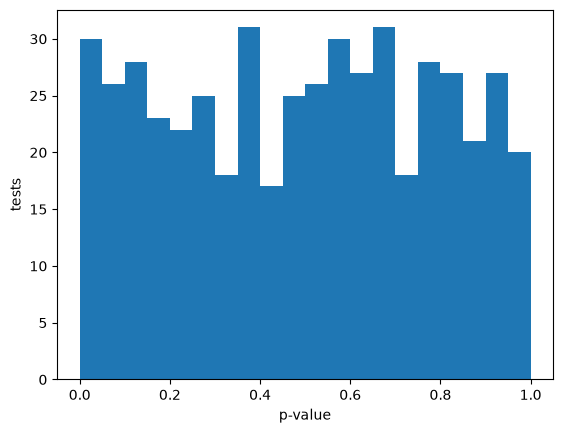

In [61]:
rng = np.random.default_rng(30)
pvalues = []
for _ in range(500):
    a = rng.random(24_000) < 0.039
    b = rng.random(24_000) < 0.039
    pvalues.append(proportions_ztest([a.sum(), b.sum()], [24_000, 24_000])[1])
pvalues = np.array(pvalues)
print(f"below 0.05: {(pvalues < 0.05).mean():.1%}   below 0.10: {(pvalues < 0.10).mean():.1%}")
print(f"below 0.50: {(pvalues < 0.50).mean():.1%}   below 0.90: {(pvalues < 0.90).mean():.1%}")
counts_per_bar, _ = np.histogram(pvalues, bins=20, range=(0, 1))
print("p-values per bar of width 0.05:", counts_per_bar)

plt.hist(pvalues, bins=20, range=(0, 1))
plt.xlabel("p-value")
plt.ylabel("tests")
plt.show()

When nothing is different, p-values are spread evenly between 0 and 1: about 5% below 0.05, half below 0.5. `np.histogram(pvalues, bins=20, range=(0, 1))` counts them in twenty bars of width 0.05 between 0 and 1, and returns the counts and the bar edges (kept in `_`); `plt.hist` with the same `bins` and `range` draws those bars: about 25 per bar, and the histogram is flat, apart from chance. That's what "a 5% false-positive rate" means, and running A/A tests like this is how teams check that their experiment platform is honest before trusting it with real ones.

**13.**

In [62]:
full = per_visitor.merge(first[["visitor_id", "device", "channel", "region"]], on="visitor_id")
model = smf.logit("enquired ~ C(variant, Treatment('control')) + C(device) + C(channel) + C(region)",
                  data=full).fit(disp=False)
out = pd.DataFrame({"odds_ratio": np.exp(model.params), "low": np.exp(model.conf_int()[0]),
                    "high": np.exp(model.conf_int()[1]), "p": model.pvalues})
print(out.round(3).to_string())

                                               odds_ratio    low   high      p
Intercept                                           0.057  0.049  0.067  0.000
C(variant, Treatment('control'))[T.variant_b]       1.145  1.046  1.253  0.003
C(device)[T.mobile]                                 0.707  0.644  0.777  0.000
C(device)[T.tablet]                                 0.700  0.567  0.864  0.001
C(channel)[T.email]                                 1.170  0.990  1.384  0.066
C(channel)[T.organic]                               0.778  0.694  0.871  0.000
C(channel)[T.paid]                                  0.657  0.571  0.756  0.000
C(channel)[T.referral]                              0.734  0.621  0.869  0.000
C(region)[T.North]                                  1.050  0.894  1.234  0.552
C(region)[T.South]                                  1.036  0.885  1.212  0.659
C(region)[T.West]                                   1.006  0.867  1.167  0.936


The variant, device, and channel coefficients keep their intervals away from 1; region's don't: region doesn't predict enquiring once the others are in the model (and section 30.6 found no regional difference in visit length either). For marketing: mobile visitors convert at around 0.7 times the odds of desktop ones, and paid traffic at about two thirds the odds of direct traffic (the reference category), so the mobile form and the paid landing pages are where the next tests belong.

**14.** Four variants means three comparisons against control, so the error rate needs handling and the sample grows:

- Test all four against one control with a **Bonferroni-corrected alpha** of 0.05 / 3 = 0.0167 for the comparisons, or use Dunnett's test (not covered here), which is designed for many-versus-one.
- The stricter alpha costs sample: at 0.0167 and 80% power for a 0.5-point effect, each group needs about 33,000 visitors rather than 25,000, and there are four groups instead of two.
- Four groups of 33,000 is 133,000 visitors; at 3,400 new visitors a day that's about **six weeks**, long enough that the site, the season, and the traffic mix will all have moved.
- The honest recommendation is usually: test the one or two variants with a real hypothesis behind them, not four because the tool allows it. If all four must run, agree in advance which comparison is primary.

**15.** The point estimate is positive, the interval crosses zero, so the test didn't settle it. Say: *"The best estimate is +0.4 points, but the range runs from −0.1 to +0.9, so this test can't tell us whether the change helps or does nothing. It does rule out anything larger than about a point."* Then choose deliberately: ship it anyway if it's cheap and the guardrails are fine (a coin-flip with a slight tilt in your favor), run longer if a decision must be right, or drop it if the upside at +0.9 still wouldn't pay for the work. What you must not do is call it a win.

**16.** Visitors come back: 12% of them have more than one session in the fortnight. If sessions were randomized, the same person could see both forms, which contaminates the comparison, and their sessions wouldn't be independent, which breaks the arithmetic behind the test. A specific way it misleads: people who enquire tend to browse more in that session, so the winning form would accumulate extra sessions, and session-level rates would drift apart for a reason that has nothing to do with the form.

**17.** *"If we keep looking until the numbers look good, we'll always find a moment when they do, even when the two forms are identical. I ran that experiment on data where nothing was different, and a quarter of the tests produced a 'winner' at some point."* Then offer the alternative: a fixed end date, or a method designed for stopping early, agreed now rather than mid-test.

**18.** Ship on the evidence you have, and put the six-week check in the plan as a commitment with a threshold attached: *"We'll review enquiry-to-order rate on 31 March; if it has dropped by more than a fifth, we revert."* Two supporting moves: track a faster proxy in the meantime (whether the sales team can reach the enquirer, which is known within days), and keep the old form available so reverting is a configuration change rather than a project.

**Checkpoint (end of the second sitting, section 30.7).** (1) The two rates are 0.06 and 0.07, so p̄ = 0.065 and p̄(1 − p̄) = 0.065 × 0.935 = 0.06078; *n* = 2 × 2.802² × 0.06078 ÷ 0.01² = 2 × 7.851 × 0.06078 ÷ 0.0001 = **about 9,540 visitors per group**. (2) `NormalIndPower().solve_power(effect_size=proportion_effectsize(0.07, 0.06), alpha=0.05, power=0.80)` gives **9,527**; the small gap is the arcsine scale again. (3) Two groups need about 19,050 email visitors. Email brings 7% of 3,400 a day, about 238, so the test takes about 80 days: **eleven to twelve weeks**. That's a long test for a landing page, and a reason to ask whether a 1-point lift is really the smallest one worth knowing about.

---

## Where this leads

- **Chapter 31, Causal Inference Without Experiments,** answers the same questions when you can't randomize: difference-in-differences, matching, and regression discontinuity.
- **Chapter 22, Statistics Without Fooling Yourself,** is the intuition this chapter computes; reread its correlation-and-causation section after this one.
- **Chapter 37, Supervised Learning Algorithms,** uses regression to *predict*, where this chapter used it to explain.
- **Chapter 75, Product Sense, Metrics, Case Studies & Guesstimates,** is about choosing and diagnosing metrics like the ones in this chapter's plan.
- **Chapter 29, Python as Software, Not Scripts,** is how an analysis like this becomes a repeatable, tested pipeline instead of a notebook nobody can rerun.
- **Chapter 56, MLOps: Making Models Survive Production,** runs experiments on models, where the treatment is a model version and the guardrails are latency and fairness.
- **Chapter 73, Statistics, Probability & Experimentation Bank,** has 37 interview questions, including A/B test debugging cases built on the faults in section 30.10 (peeking, Q73-025; the sample-ratio check, Q73-026; novelty and multiple testing in its rapid-fire table).